**Proyecto:** Análisis de la Mortalidad Fetal Potencialmente Prevenible en   Ecuador mediante Clustering y Modelos de Clasificación para la Identificación de Perfiles de Vulnerabilidad Materna

---



**Antecedentes:**  Una vez realizado todo el proceso de limpieza y normalización del Dataset, el cual consistió en:

**1. Corrección de Codificación (BOM):** Se detectó la presencia de caracteres Byte Order Mark (ï»¿) en el encabezado del archivo original, los cuales fueron eliminados mediante la decodificación utf-8-sig para permitir el acceso correcto a la primera variable (prov_insc).

**2. Normalización de Metadatos:** Se aplicó una función de limpieza de espacios en blanco (stripping) a los nombres de las 43 variables para evitar errores de referencia en el diccionario de datos.

**3. Depuración de Registros Malformados:** Durante la carga, se descartaron registros con inconsistencias en los delimitadores (filas con exceso de columnas por errores de digitación en origen), resultando en una cantidad efectiva de 1.328 registros.

**4. Alineación con Diccionario ANDA-INEC:** Se vincularon las variables técnicas con sus descripciones oficiales para asegurar la trazabilidad institucional del estudio.

**5. Detección de Valores Atípicos**

Se identificaron las variables que presentan códigos de no respuesta, con el fin de determinar la estrategia de limpieza y evitar sesgos en el algoritmo de agrupamiento.

**6. Refinamiento por Criterio de Variables Críticas**

Dentro de las variables que presentan valores atípicos, se han identificado un conjunto de 7 variables críticas que representan el perfil socio-demográfico y clínico necesario para el modelado de vulnerabilidad: edad_mad, sem_gest, con_pren, niv_inst, sabe_leer, etnia y est_civil.

Para asegurar la precisión del algoritmo de Clustering, se opta por una depuración que consiste en la eliminación de los registros que presenten omisiones o falta de información en cualquiera de estas dimensiones.

Esto permite trabajar con datos de integridad elevada, evitando que valores nulos distorsionen la formación de los grupos de riesgo.

**7. Imputación de Variables Antropométricas**

Se han identificado 2 variales continuas (peso y talla) que presentan valores atípicos, se optó por una estrategia de imputación por mediana, esta decisión se fundamenta en la capacidad de la mediana para resistir la influencia de valores atípicos presentes en los registros de defunciones fetales.

Al mantener la tendencia central de la muestra, se preserva la integridad del volumen de datos sin sesgar las mediciones físicas que son críticas para la determinación de los clústeres de riesgo.

**8. Imputación de Variables de Antecedentes de Paridad**

Para las variables (hij_viv) e (hij_vivm), los registros identificados con la etiqueta "Sin información" fueron tratados mediante imputación por moda. Se selecciona esta técnica debido a que estas variables son de naturaleza discreta y presentan una distribución sesgada donde la mayoría de la población se concentra en un valor específico. Este procedimiento permite conservar la representatividad de la muestra sin introducir distorsiones significativas en el cálculo de distancias para el Clustering.

**9. Justificación de Variables Sin Intervención**

Se ha determinado no aplicar procesos de depuración, transformación o imputación sobre las variables (nac_mad) nacionalidad de la madre y (dia_mad) día de nacimiento de la madre debido a que estas dimensiones actúan como datos de registro civil y control de identidad, careciendo de una relación causal directa con la variabilidad biológica del fenómeno de mortalidad fetal en el contexto de este modelo de clustering, sin embargo, se optó por conservar estas variables en su estado original únicamente para fines de consulta o trazabilidad de los datos, garantizando que el espacio de características del modelo se concentre exclusivamente en factores clínicos y sociodemográficos de alto impacto.


---




**Consolidación del Dataset**

Tras completar el ciclo de preprocesamiento, se consolida el Dataset que constituye el universo total de la investigación, esta base de datos representa la totalidad de los registros depurados que cumplen con estándares de calidad adecuados

La eliminación de ruidos y la normalización garantizan que cualquier inferencia realizada sobre este universo sea estadísticamente sólida.

El dataset analizado cuenta con un universo total de 1.184 registros y 43 variables de análisis. El Índice de Integridad global (99.94%) evidencia un alto nivel de completitud de la información, lo que permite avanzar hacia las etapas de análisis.

---



**Integridad por Variable**

A continuación se presenta una tabla que muestra la integridad por cada una de las variables del Dataset

In [ ]:
import pandas as pd
from IPython.display import display, HTML


tabla_variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo Original": df.dtypes.astype(str),
    "Registros totales": len(df),
    "Registros no nulos": df.notna().sum().values,
    "Registros nulos": df.isna().sum().values
})

tabla_variables["% Completitud"] = (
    tabla_variables["Registros no nulos"] / tabla_variables["Registros totales"] * 100
).round(2)

tabla_variables["% Missing"] = (
    tabla_variables["Registros nulos"] / tabla_variables["Registros totales"] * 100
).round(2)


def clasificar(row):
    nom = row['Variable'].lower()
    tipo = row['Tipo Original']
    if 'fecha' in nom:
        return 'Temporal (Fecha)'
    elif any(x in nom for x in ['anio', 'mes', 'dia']):
        return 'Temporal (Componente)'
    elif 'int' in tipo:
        return 'Numérica (Discreta)'
    elif 'float' in tipo:
        return 'Numérica (Continua)'
    else:
        return 'Categórica (Cualitativa)'

tabla_variables['Tipo'] = tabla_variables.apply(clasificar, axis=1)


tabla_variables['Descripción'] = tabla_variables['Variable'].map(diccionario_completo)


tabla_variables = tabla_variables[[
    'Variable',
    'Descripción',
    'Tipo Original',
    'Tipo',
    'Registros totales',
    'Registros no nulos',
    'Registros nulos',
    '% Completitud',
    '% Missing'
]]


tabla_variables = tabla_variables.sort_values(
    by='% Completitud',
    ascending=True
).reset_index(drop=True)


estilo_tabla = """
<style>
    table {
        width: 100%;
        border-collapse: collapse;
    }
    th {
        background-color: #2c3e50;
        color: white;
        text-align: center !important;
        padding: 10px;
    }
    td {
        text-align: center !important;
        padding: 8px;
        border: 1px solid #ddd;
    }
    tr:nth-child(even) {background-color: #f2f2f2;}
    tr:hover {background-color: #ddd;}
</style>
"""


display(HTML(estilo_tabla + tabla_variables.to_html(index=False)))


Variable,Descripción,Tipo Original,Tipo,Registros totales,Registros no nulos,Registros nulos,% Completitud,% Missing
dia_mad,Día de nacimiento de la madre,float64,Temporal (Componente),1184,1154,30,97.47,2.53
nac_mad,Nacionalidad de la madre,object,Categórica (Cualitativa),1184,1183,1,99.92,0.08
prov_insc,Provincia donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
cant_insc,Cantón donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
mes_insc,Mes de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
dia_insc,Día de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
parr_insc,Parroquia donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
anio_insc,Año de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
peso,Peso del feto (gramos a 4 dígitos),float64,Numérica (Continua),1184,1184,0,100.00,0.00
sem_gest,Semanas de gestación,int64,Numérica (Discreta),1184,1184,0,100.00,0.00


La clasificación de variables se realizó considerando tanto el tipo técnico del dato como su rol analítico, permitiendo diferenciar variables temporales, numéricas y categóricas de forma consistente con su uso posterior en análisis exploratorio y modelado.

---



**Subconjuntos y definición de variables de interés**

Para el desarrollo del análisis se identificaran variables clave, clasificadas según su rol dentro del modelo analítico, orientadas a capturar la desigualdad en el acceso a la salud y el riesgo reproductivo:

**Variables explicativas**

Incluyen dimensiones geográficas, biológicas, contextuales y de atención que actúan como determinantes del desenlace fetal.

**1. Variables Geográficas:** Identifican los nodos críticos de mortalidad y las brechas de infraestructura. El análisis del Área, urbana o rural, es fundamental para evidenciar la desigualdad, ya que las zonas rurales suelen presentar mayores barreras de acceso, deficiencias en el transporte y tiempos de traslado más prolongados hacia centros de especialidad.

El contraste entre el lugar de residencia y el de fallecimiento permite, además, inferir la lejanía como un factor de riesgo.

* Área de fallecimiento (area_fall)
* Provincia de fallecimiento (prov_fall)
* Cantón de fallecimiento (cant_fall)
* Parroquia de fallecimiento (parr_fall)
* Provincia de residencia de la madre (prov_res)
* Cantón de residencia de la madre (cant_res)
* Parroquia de residencia de la madre (parr_res)
* Área de residencia de la madre (area_res)


**2. Características Biológicas y de Desarrollo:** Estas variables permiten caracterizar la madurez física y la viabilidad del feto al momento del fallecimiento. Son indicadores directos del desarrollo intrauterino y actúan como señales de alerta sobre la salud de la madre y la efectividad de la vigilancia médica durante la gestación.

* Peso (peso)
* Talla (talla)
* Edad Gestacional (sem_gest)


**3. Determinantes de Acceso y Atención:** Miden la oportunidad y la calidad de la respuesta del sistema de salud ante el embarazo. El lugar de ocurrencia y la persona que atiende el evento reflejan el grado de institucionalización y profesionalización de la asistencia recibida, estos factores son determinantes en la evitabilidad del deceso.

* Número de Controles prenatales (con_pren)
* Persona que atendió el parto (asis_por)
* Causa que ocasionó la defunción fetal (causa_fetal)
* Lugar de ocurrencia (lugar_ocur)

**4. Factores de Vulnerabilidad Materna:** Representan el perfil sociodemográfico y educativo de la madre, estas variables son cruciales para entender cómo los determinantes sociales, nivel de instrucción, etnia o  condición de extranjería, condicionan el acceso a la información y a los servicios de salud, exponiendo a ciertos grupos a una mayor exclusión y riesgo.

* Edad de la madre (edad_mad)
* Nivel de instrucción (niv_inst)
* Alfabetismo e instrucción de la madre (sabe_leer)
* Etnia (etnia)
* Estado Civil (est_civil)
* Nacionalidad de la madre (nac_mad)

**5. Antecedentes Reproductivos:** Esta dimensión de variables actúa como un predictor de riesgo obstétrico acumulado, ya que el historial de pérdidas previas permite identificar perfiles de riesgo recurrente que requieren una atención diferenciada y una intervención más intensiva por parte de los servicios de salud.

* Hijos nacidos muertos (hij_nacm)

La creación de subconjuntos a partir de estas variables permite:

**1. Identificar patrones diferenciados de riesgo:** Al aislar, por ejemplo, el área rural o los niveles bajos de instrucción, el algoritmo puede detectar clústeres de vulnerabilidad que en el dataset general quedarían ocultos.

**2. Reducir el ruido estadístico:** Permite separar los casos de mortalidad por causas biológicas inevitables de aquellos derivados de la desigualdad territorial.

**3. Facilitar la interpretación:** Los perfiles obtenidos permiten generar recomendaciones de política pública específicas para cada territorio y grupo social.

---




**Distribuciones y detección de outliers (análisis univariado)**

El análisis de las distribuciones univariadas de las **variables biológicas y reproductivas**  permite caracterizar la estructura estadística de los datos y detectar posibles valores atípicos que puedan influir en etapas posteriores de modelado. Dado que el evento analizado corresponde a defunciones fetales, es esperable encontrar distribuciones no simétricas, con colas largas y concentraciones en rangos clínicamente críticos, reflejando condiciones adversas del desarrollo intrauterino y del contexto materno.

La identificación de asimetrías, dispersiones extremas y acumulaciones en determinados valores es fundamental para evaluar la calidad de la información, distinguir entre outliers reales y posibles errores de registro, y definir estrategias adecuadas de limpieza, transformación o segmentación de los datos.

El análisis se presenta para las siguientes variables:

* Peso del feto (gramos, a cuatro dígitos)
* Talla del feto
* Semanas de gestación
* Edad de la madre
* Controles prenatales recibidos
* Hijos nacidos muertos

Las variables continuas se visualizan mediante histogramas acompañados de estimaciones de densidad (KDE), mientras que las variables discretas se visualizan utilizando histogramas con valores enteros, garantizando una interpretación coherente con su naturaleza y evitando distorsiones asociadas a interpolaciones no significativas.

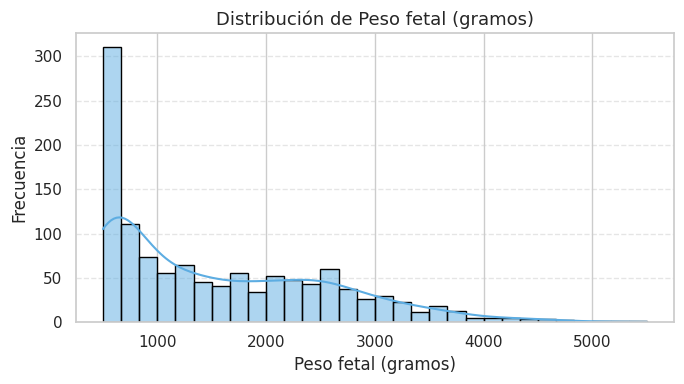

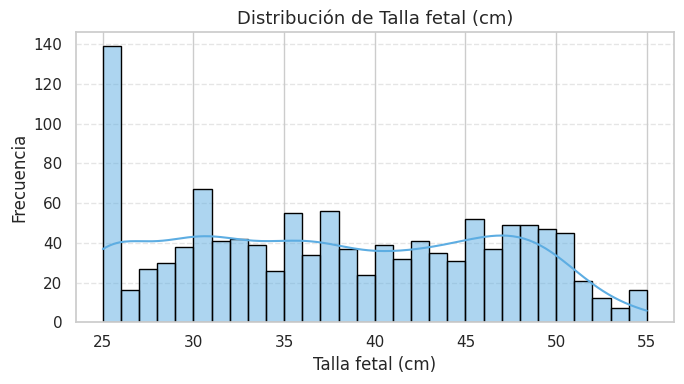

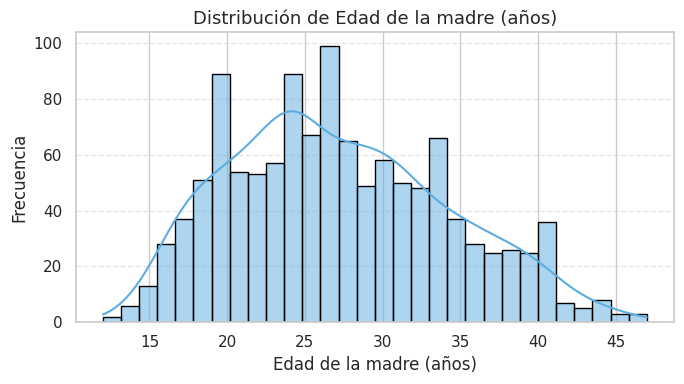

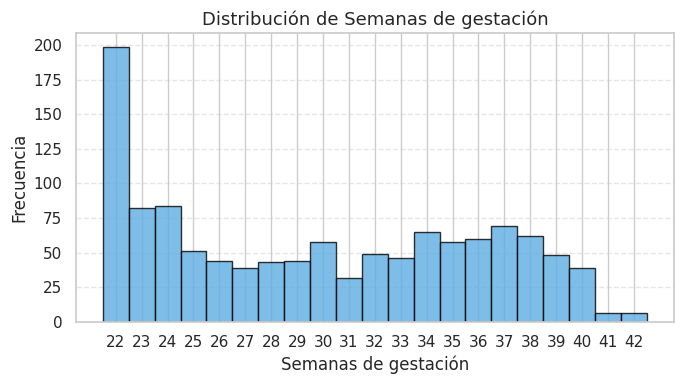

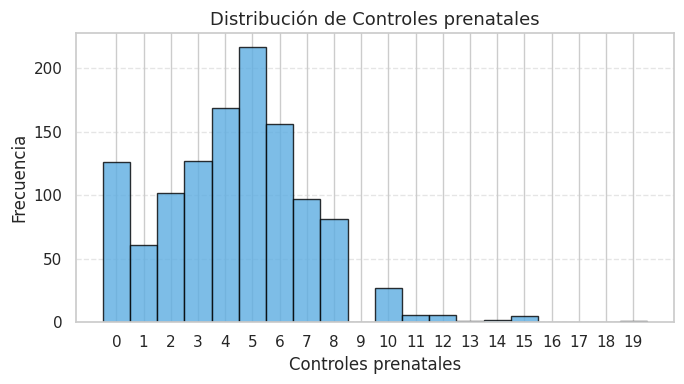

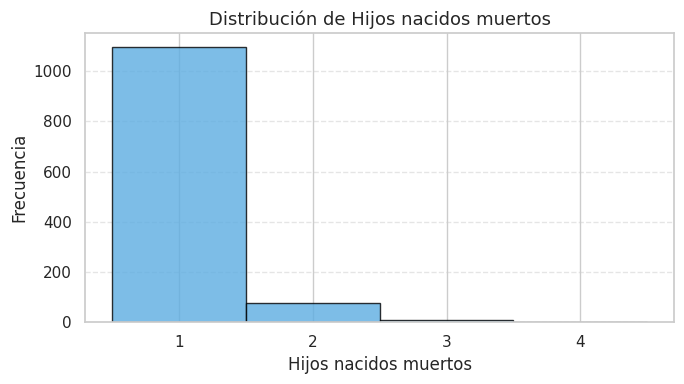

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


variables_continuas = ['peso', 'talla', 'edad_mad']
variables_discretas = ['sem_gest', 'con_pren', 'hij_nacm']


titulos = {
    'peso': 'Peso fetal (gramos)',
    'talla': 'Talla fetal (cm)',
    'sem_gest': 'Semanas de gestación',
    'edad_mad': 'Edad de la madre (años)',
    'con_pren': 'Controles prenatales',
    'hij_nacm': 'Hijos nacidos muertos'
}


sns.set_style("whitegrid")
color_azul = '#5DADE2'

def plot_distribucion(df, variable, tipo):

    data = df[variable].dropna()
    titulo = titulos.get(variable, variable)

    plt.figure(figsize=(7, 4))


    if tipo == 'continua':
        sns.histplot(
            data,
            kde=True,
            bins=30,
            color=color_azul,
            edgecolor='black'
        )


    elif tipo == 'discreta':
        data = data.astype(int)
        min_val = data.min()
        max_val = data.max()
        bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

        plt.hist(
            data,
            bins=bins,
            color=color_azul,
            edgecolor='black',
            alpha=0.8
        )
        plt.xticks(range(min_val, max_val + 1))

    plt.title(f'Distribución de {titulo}', fontsize=13)
    plt.xlabel(titulo)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


for var in variables_continuas:
    plot_distribucion(df, var, 'continua')

for var in variables_discretas:
    plot_distribucion(df, var, 'discreta')


**Boxplots – detección de outliers**

Si bien el análisis de distribuciones permite identificar la forma general, asimetrías y concentraciones de las variables, este enfoque resulta limitado para evaluar de manera precisa la magnitud y localización de valores extremos.

En contextos como el de la mortalidad fetal, la presencia de observaciones atípicas no necesariamente implica errores de medición, sino que puede representar eventos clínicamente críticos o perfiles de riesgo extremo que requieren una interpretación diferenciada.

Con el objetivo de profundizar en la detección sistemática de outliers y evaluar su impacto potencial sobre los análisis multivariados, se complementa el análisis univariado mediante boxplots. Esta visualización permite identificar rangos intercuartílicos, dispersión central y valores extremos de forma comparativa entre variables, facilitando la toma de decisiones sobre estrategias de tratamiento de outliers, tales como su conservación, segmentación o el uso de métodos robustos en etapas posteriores de modelado.

Este análisis es particularmente relevante para variables biológicas y reproductivas, donde los valores extremos pueden estar asociados a condiciones estructurales de vulnerabilidad, fallas en el acceso oportuno a servicios de salud o antecedentes obstétricos de alto riesgo, elementos centrales para la identificación de perfiles de vulnerabilidad materna

Este análisis busca identificar valores extremos que puedan representar riesgo biológico, errores de registro o eventos poco frecuentes relevantes para el análisis de mortalidad fetal.

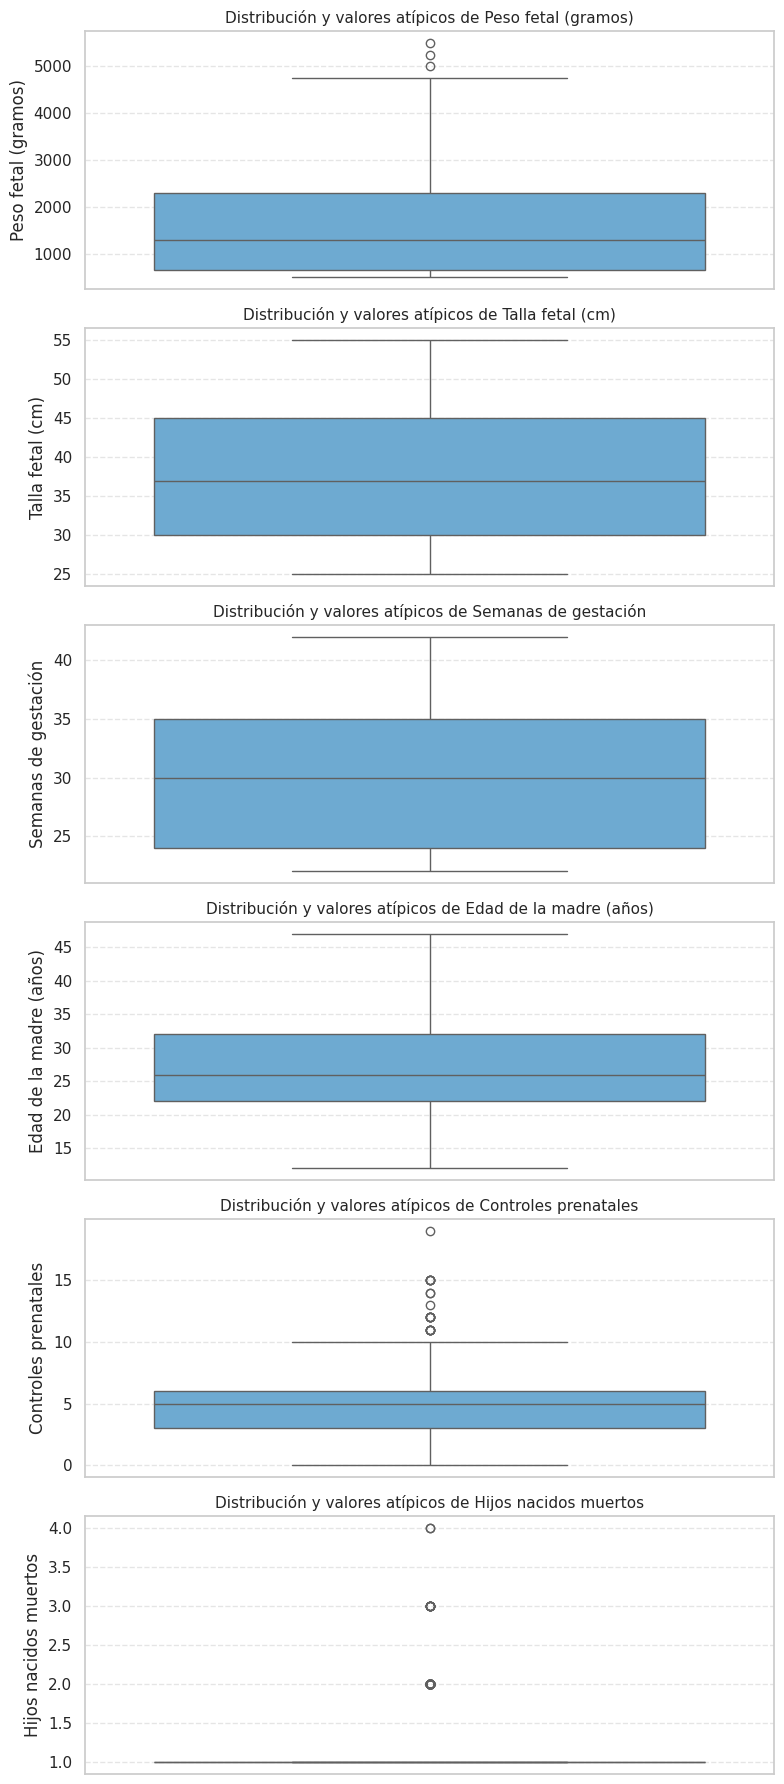

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
color_azul = '#5DADE2'


variables = [
    ('peso', 'Peso fetal (gramos)'),
    ('talla', 'Talla fetal (cm)'),
    ('sem_gest', 'Semanas de gestación'),
    ('edad_mad', 'Edad de la madre (años)'),
    ('con_pren', 'Controles prenatales'),
    ('hij_nacm', 'Hijos nacidos muertos')
]


fig, axes = plt.subplots(len(variables), 1, figsize=(8, 18))

for ax, (var, label) in zip(axes, variables):
    sns.boxplot(
        y=df[var],
        color=color_azul,
        ax=ax
    )
    ax.set_title(f'Distribución y valores atípicos de {label}', fontsize=11)
    ax.set_ylabel(label)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Análisis de Correlación de "Esfuerzo de Atención" y Viabilidad Biológica**

Se evalúa la relación entre las variables cuantitativas que determinan la viabilidad del feto frente a la intervención del sistema de salud. Para este propósito, se utiliza el Coeficiente de Correlación de Rangos de Spearman ($\rho$).

Justificación técnica: Se opta por Spearman en lugar de Pearson debido a que variables como el "Número de controles prenatales" (con_pren) y la "Edad gestacional" (sem_gest) presentan distribuciones no normales, datos discretos (con saltos) y posibles relaciones no lineales.

Spearman permite capturar relaciones monótonas de manera robusta ante valores atípicos.

Objetivos del análisis:

* Identificar el riesgo por edad materna: Evaluar si existe una correlación negativa entre edad_mad y sem_gest, lo cual indicaría que los extremos de la vida reproductiva se asocian a partos prematuros.
* Evaluar la eficacia del control prenatal: Analizar la correlación positiva entre con_pren y el peso/talla del feto. Una correlación débil en este punto sugeriría que el incremento en la cantidad de controles no se traduce necesariamente en un mejor desarrollo fetal, apuntando a deficiencias en la calidad de la atención.
* Detección de Riesgo Acumulado: Observar la relación entre el historial de pérdidas previas (hij_nacm) y la viabilidad del embarazo actual.

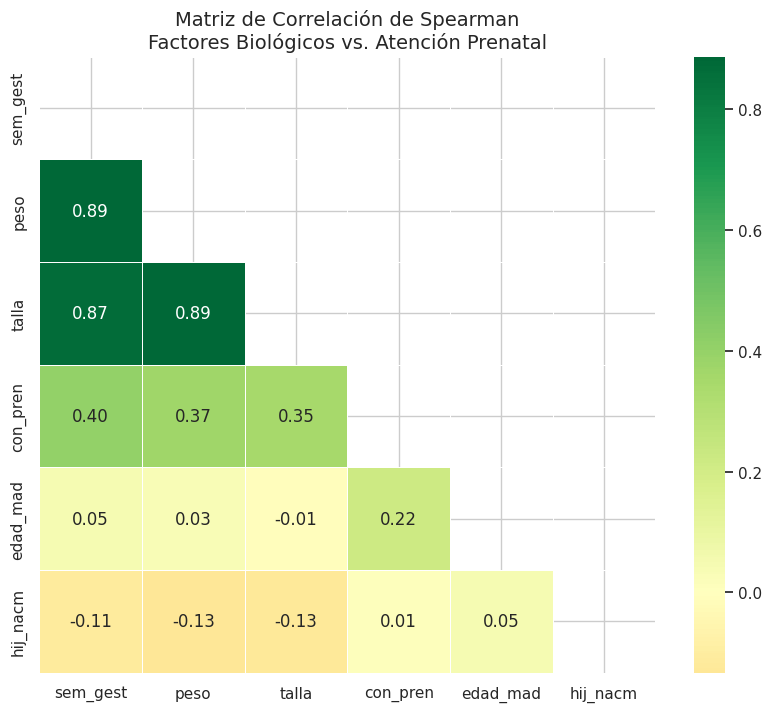

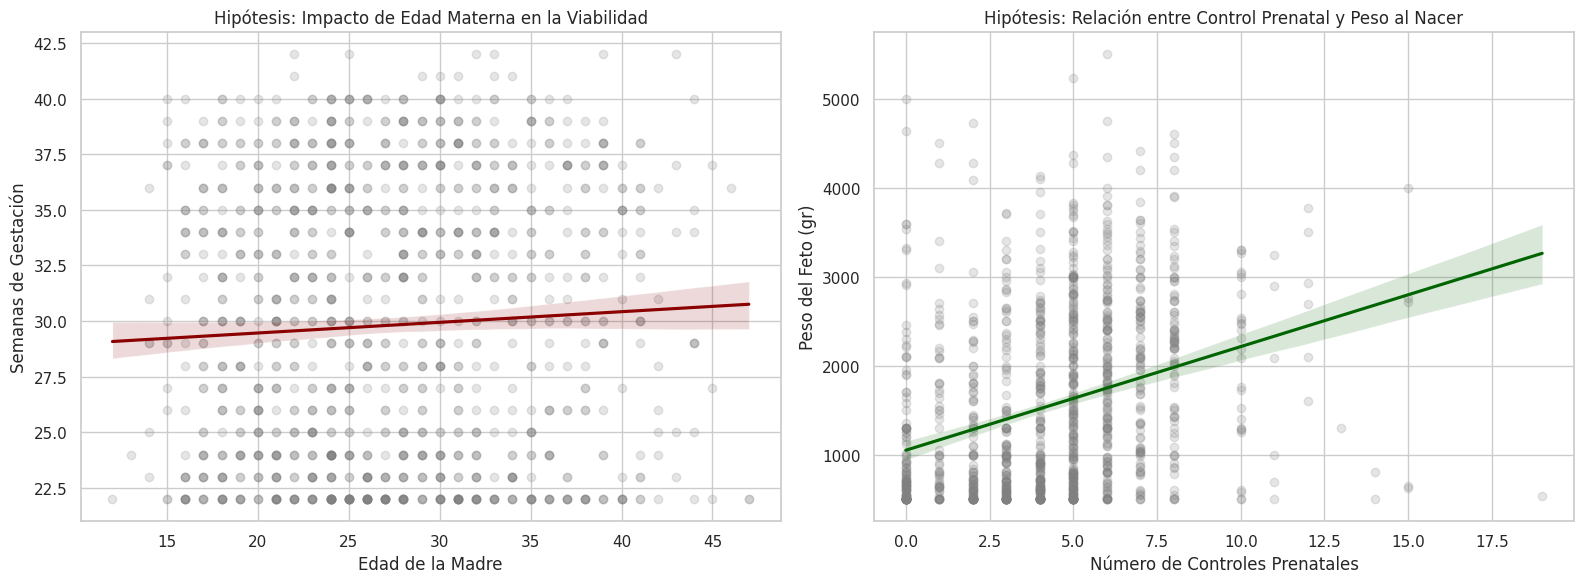

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


file_path = 'dataset__limpio.csv'
df = pd.read_csv(file_path)


vars_interes = ['sem_gest', 'peso', 'talla', 'con_pren', 'edad_mad', 'hij_nacm']


df_subset = df[vars_interes].dropna()


corr_spearman = df_subset.corr(method='spearman')


plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

sns.heatmap(corr_spearman,
            mask=mask,
            annot=True,
            cmap='RdYlGn',
            fmt=".2f",
            center=0,
            square=True,
            linewidths=.5)

plt.title('Matriz de Correlación de Spearman\nFactores Biológicos vs. Atención Prenatal', fontsize=14)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.regplot(ax=axes[0], x='edad_mad', y='sem_gest', data=df_subset,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'darkred'})
axes[0].set_title('Hipótesis: Impacto de Edad Materna en la Viabilidad')
axes[0].set_xlabel('Edad de la Madre')
axes[0].set_ylabel('Semanas de Gestación')


sns.regplot(ax=axes[1], x='con_pren', y='peso', data=df_subset,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'darkgreen'})
axes[1].set_title('Hipótesis: Relación entre Control Prenatal y Peso al Nacer')
axes[1].set_xlabel('Número de Controles Prenatales')
axes[1].set_ylabel('Peso del Feto (gr)')

plt.tight_layout()
plt.show()

In [ ]:

valor_correlacion = df[['con_pren', 'sem_gest']].corr(method='spearman').iloc[0,1]
print(f"Coeficiente de Spearman: {valor_correlacion}")

Coeficiente de Spearman: 0.4017388573421682


**El Triángulo Biológico (Peso, Talla, Semanas de gestación)**: Correlación de 0.87 a 0.89

Existe una relación lineal casi perfecta. Esto confirma la consistencia de los datos: a más tiempo de gestación, mayor crecimiento.

Estas tres variables se comportan como una sola "dimensión de madurez". Si un clúster tiene valores altos aquí pero el desenlace es muerte, estamos ante el escenario de mayor prevenibilidad, pues el feto ya era biológicamente viable.

**Control Prenatal (con_pren):** Correlación de  0.35 a 0.40

La correlación con el peso y semanas de gestación es positiva pero moderada, lo que indica que el control prenatal ayuda, pero no garantiza el éxito.

Los resultados sugieren que hay un grupo de madres que, a pesar de tener controles, no logran que el feto llegue a término o gane peso, aquí es donde entra la oportunidad de mejora de Calidad de Atención.

**Edad Materna (edad_mad)**: Correlación de 0.05 a 0.01

Estos resultados indican que la edad de la madre no parece determinar la duración del embarazo o el peso del feto de forma directa en este dataset, esto desafía la literatura tradicional que culpa a la edad (adolescente o avanzada) como causa única, lo que indica que la causa de la muerte fetal no es la edad de la madre, sino factores externos.

**El Historial de Riesgo Silencioso**: Correlación de -0.11 a -0.13

Existe una tendencia leve, a más hijos nacidos muertos anteriormente, menor es el peso y las semanas del embarazo actual, aun que la corrrelación es débil, el signo negativo es consistente, lo que indica un riesgo acumulado, esta variable será un "activador" de alerta para perfiles de vulnerabilidad recurrente.


**Correlación Edad Materna y Controles** Correlación 0.22

Las madres de mayor edad tienden a tener ligeramente más controles que las jóvenes, esto sugiere que las madres jóvenes o adolescentes podrían estar más expuestas por falta de adherencia al control prenatal.


**El análisis de Spearman** revela que, si bien la viabilidad biológica sigue patrones esperados (Peso/Semanas), la intervención del sistema de salud (Controles Prenatales) muestra una eficacia moderada ($\rho \approx 0.40$). La casi nula correlación de la edad materna con los indicadores de desarrollo fetal sugiere que la mortalidad en este grupo de estudio responde a determinantes distintos a la biología reproductiva básica, reforzando la hipótesis de que factores socio-territoriales y de gestión hospitalaria son los principales moduladores del desenlace fatal.


El gráfico de **Edad de la Madre vs. Semanas de Gestación** muestra una línea de regresión plana y una correlación casi nula ($\rho = 0.05$).
Al no ser la biología de la edad el factor determinante, se puede demostrar que la vulnerabilidad (instrucción, etnia, acceso geográfico) es la que realmente empuja estos casos hacia el desenlace fatal.

El gráfico de **Controles Prenatales vs. Peso Fetal** muestra una pendiente positiva ($\rho = 0.37$), pero con una dispersión muy alta.
Si bien más controles ayudan, la relación es moderada, se observa que hay fetos con muchos controles (10 o más) que siguen naciendo con pesos extremadamente bajos o en semanas tempranas. Esto sugiere que cumplir con el número de citas no garantiza el éxito si la calidad de la atención o la capacidad de resolución del centro de salud es baja.

**Identificación de la Prevenibilidad:** Aquellos puntos con muchos controles y bajo peso o pocas semanas son los llamados falsos protegidos, es decir, madres que hicieron lo correcto siguiendo el sistema, pero el sistema falló en proteger la viabilidad del feto, estos son los casos de mortalidad potencialmente prevenible por gestión.

**Conclusión:** Los resultados confirman que la viabilidad fetal en el contexto ecuatoriano no está condicionada por la edad materna ($\rho = 0.05$), lo que desplaza el foco del análisis hacia determinantes extrínsecos. Por otro lado, la relación moderada entre el control prenatal y el peso ($\rho = 0.37$) evidencia una brecha en la eficacia del sistema: la asistencia a controles es una condición necesaria pero no suficiente para garantizar la viabilidad, sugiriendo fallas estructurales en la detección oportuna de riesgos.

**Análisis de la Sincronía del Desarrollo Fetal: El Triángulo Biológico**

La relación entre el peso, la talla y las semanas de gestación constituye lo que se denomina el 'Triángulo Biológico'. Este análisis es fundamental para validar la integridad de los datos y, sobre todo, para establecer la línea base de viabilidad del feto al momento del fallecimiento.

A diferencia de los determinantes sociales, que presentan una alta variabilidad, las variables biológicas en condiciones normales deben mostrar una progresión lineal y altamente correlacionada.

El objetivo de este análisis es:

1. Validar la consistencia clínica: Confirmar que los registros de óbitos fetales siguen las leyes del desarrollo intrauterino (a mayor edad gestacional, mayor peso y talla).

2. Identificar el umbral de viabilidad: Visualizar la densidad de casos que alcanzan semanas de gestación y pesos considerados como 'viables' según los estándares de la OMS (generalmente >22 semanas o >500 gramos), lo cual permite dimensionar la magnitud de la muerte fetal que ocurre en etapas donde la medicina moderna tiene mayores oportunidades de intervención.

A continuación, se presenta una matriz de dispersión segmentada por Área de Residencia, con el fin de observar si el entorno geográfico de la madre altera estas trayectorias de crecimiento biológico o si la vulnerabilidad territorial se manifiesta de forma externa a la biología fetal."

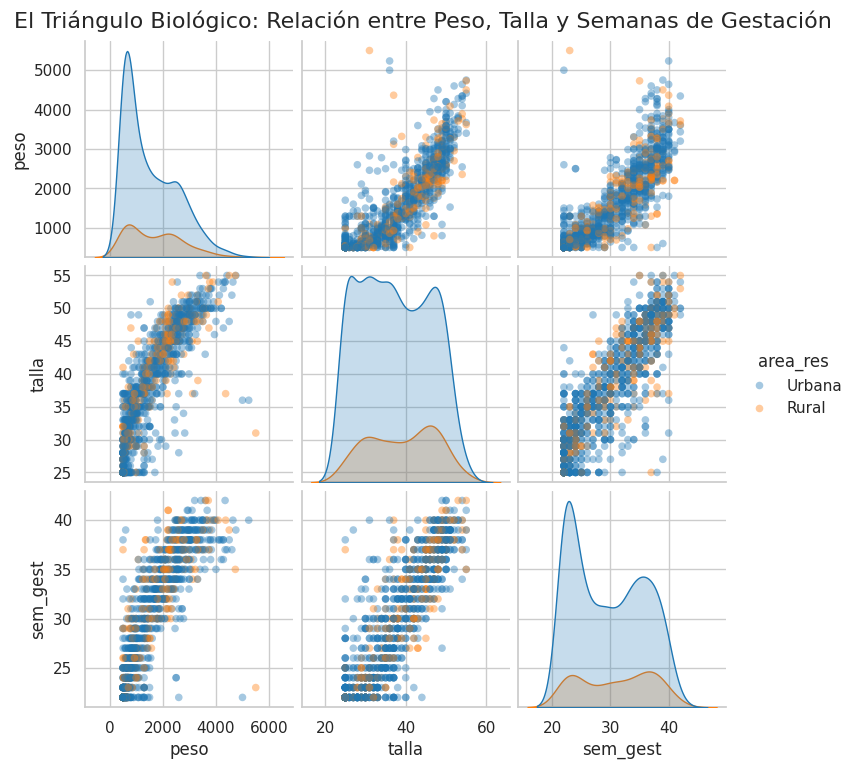

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('dataset__limpio.csv')


biotriangulo = ['peso', 'talla', 'sem_gest', 'area_res']
df_bio = df[biotriangulo].dropna()


g = sns.pairplot(
    df_bio,
    hue='area_res',
    palette={'Urbana': '#1f77b4', 'Rural': '#ff7f0e'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 30, 'edgecolor': 'none'}
)


g.fig.suptitle('El Triángulo Biológico: Relación entre Peso, Talla y Semanas de Gestación', y=1.02, fontsize=16)
plt.show()

**Interpretación de Resultados:**

1. Sincronía Biológica Universal

El análisis mediante pairplot demuestra que el crecimiento intrauterino (peso y talla) mantiene una sincronía robusta con la edad gestacional ($\rho > 0.85$), independientemente del área de residencia. Este hallazgo es fundamental: confirma que el fenómeno de la muerte fetal en Ecuador no discrimina la capacidad biológica de desarrollo. Tanto en entornos urbanos como rurales, los fetos siguen la misma trayectoria de madurez, lo que permite utilizar estas variables como un estándar de viabilidad para el modelo de clasificación.

2. El Hallazgo de la "Biología Equitativa" vs. "Acceso Desigual"

Uno de los puntos más reveladores es que las distribuciones de densidad (KDE) no muestran un desplazamiento significativo hacia la izquierda en las zonas rurales. Esto sugiere que la mortalidad fetal rural no se debe necesariamente a fetos más débiles o pequeños, sino que, ante fetos de similar desarrollo biológico, el sistema de salud o el entorno territorial no ofrece la misma capacidad de respuesta que en la zona urbana.

3. Definición del Perfil de Prevenibilidad

La fuerte correlación observada permite establecer una "zona de viabilidad" en el gráfico (generalmente situada en el cuadrante superior derecho: $>28$ semanas, $>1000$g y $>35$cm). Los puntos acumulados en esta zona representan el núcleo de la "Mortalidad Fetal Potencialmente Prevenible".
Si la sincronía biológica era la adecuada para la supervivencia fuera del útero, la causa de la defunción debe buscarse en el Patient Journey (falta de controles o atención deficiente en el parto) o en las Barreras Geográficas (demoras en el traslado).

4. Hacia el Modelado de Vulnerabilidad

Dado que el entorno geográfico no altera la biología fundamental, se confirma la hipótesis de que las vulnerabilidades territoriales son extrínsecas. Para el clustering, esto significa que el algoritmo no agrupará a las madres rurales por una "biología diferente", sino por la desconexión entre su necesidad biológica (un feto viable) y la respuesta sanitaria recibida.

**Análisis de Independencia: Brecha Territorial en el Acceso a Salud**

Para validar la hipótesis de la fragmentación territorial, se aplicó una prueba de Chi-cuadrado de Pearson evaluando la relación entre el Área de Residencia (Urbana/Rural) y la Suficiencia de Controles Prenatales (categorizada como Insuficiente 0-4 y Suficiente 5+ según estándares de la OMS).

Para evitar el sesgo por edad gestacional, se definió la variable 'Suficiencia Dinámica de Controles' siguiendo estas reglas:

* Si murió en el 1er Trimestre (≤ 12 sem): Debe tener al menos 1 control.
* Si murió en el 2do Trimestre (13 - 27 sem): Debe tener al menos 3 controles (el del 1ero + 2 del 2do).
* Si murió en el 3er Trimestre (≥ 28 sem): Debe tener al menos 5 a 7 controles (dependiendo de la semana exacta).

Esto permite diferenciar entre la falta de acceso al sistema y la interrupción biológica temprana del embarazo

Este análisis busca determinar si el entorno geográfico condiciona de manera significativa la oportunidad de atención. Un resultado estadísticamente significativo confirmaría que la residencia rural actúa como un factor de exclusión sistémico, donde la lejanía o la falta de infraestructura se traduce en una trayectoria de control deficiente. Este hallazgo es el precursor para el modelo de clustering, permitiendo segmentar perfiles de vulnerabilidad basados en el aislamiento geográfico.

<Figure size 1000x600 with 0 Axes>

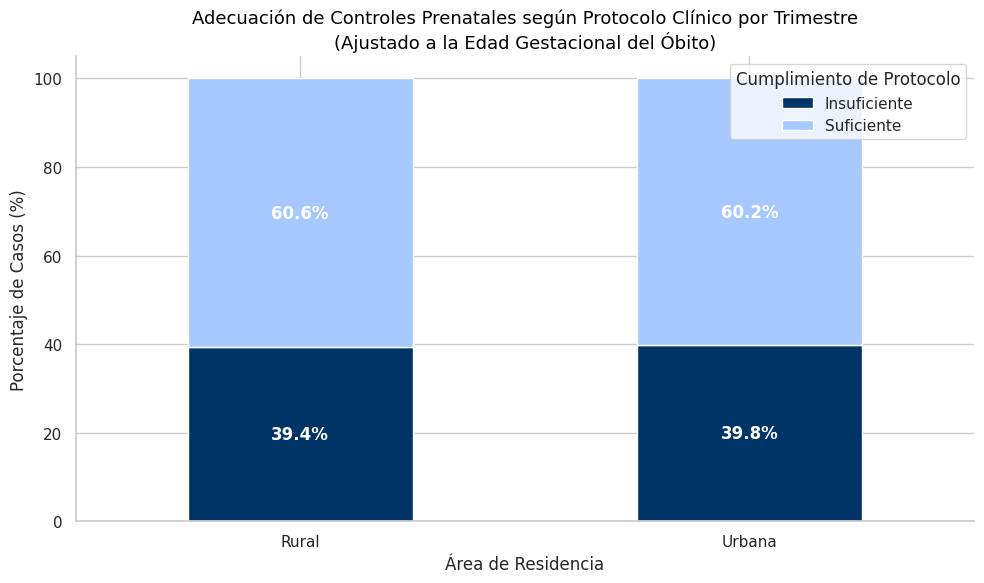

--- Resultados con Lógica Clínica ---
Valor p (Chi-cuadrado): 0.9723


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


df = pd.read_csv('dataset__limpio.csv')


def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']


    if semanas <= 12:
        meta = 1
    elif semanas <= 27:
        meta = 3
    elif semanas <= 33:
        meta = 4
    elif semanas <= 35:
        meta = 5
    elif semanas <= 37:
        meta = 6
    else:
        meta = 7

    if controles >= meta:
        return 'Suficiente (Protocolo)'
    else:
        return 'Insuficiente (Protocolo)'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)


tabla_clinica = pd.crosstab(df['area_res'], df['control_clinico'])
chi2, p, dof, ex = chi2_contingency(tabla_clinica)


plt.figure(figsize=(10, 6))
tabla_pct = tabla_clinica.div(tabla_clinica.sum(1), axis=0) * 100

azul_fuerte = "#003366"
azul_claro = "#A6C8FF"

ax = tabla_pct.plot(kind='bar', stacked=True, color=[azul_fuerte, azul_claro], figsize=(10, 6), rot=0)


plt.title('Adecuación de Controles Prenatales según Protocolo Clínico por Trimestre\n(Ajustado a la Edad Gestacional del Óbito)',
          fontsize=13,
          fontweight='normal',
          color='black')

plt.ylabel('Porcentaje de Casos (%)', fontsize=12)
plt.xlabel('Área de Residencia', fontsize=12)
plt.legend(title='Cumplimiento de Protocolo', labels=['Insuficiente', 'Suficiente'], loc='upper right')

for p_bar in ax.patches:
    width, height = p_bar.get_width(), p_bar.get_height()
    x, y = p_bar.get_xy()
    if height > 0:
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center',
                color='white' if height > 40 else 'white', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print(f"--- Resultados con Lógica Clínica ---")
print(f"Valor p (Chi-cuadrado): {p:.4f}")

Este gráfico muestra el porcentaje de casos de mortalidad fetal con controles prenatales Insuficientes o Suficientes según un protocolo clínico ajustado por el trimestre de gestación, diferenciado por el área de residencia (Rural vs. Urbana).

**Suficiencia de Controles**

Tanto en las áreas rurales como urbanas, la mayoría de los casos de mortalidad fetal (aproximadamente el 60%) cumplieron con el protocolo clínico de controles prenatales ajustado por trimestre.

El resultado más importante es que, al ajustar la suficiencia de controles prenatales según la edad gestacional del óbito, no hay una diferencia estadísticamente significativa en el cumplimiento del protocolo entre las áreas rurales y urbanas (p-value = 0.9723, que es mucho mayor que el umbral común de 0.05). Esto significa que, contrario a la expectativa inicial, la residencia rural no se traduce automáticamente en una mayor insuficiencia de controles prenatales cuando se considera la etapa del embarazo en la que ocurrió el fallecimiento fetal.

Este hallazgo es crucial porque sugiere que la causa de la mortalidad fetal potencialmente prevenible en Ecuador no se debe a una simple falta de acceso o adherencia a los controles prenatales en las zonas rurales. En cambio, si las madres asisten a los controles de manera similar en ambos entornos, la atención debe centrarse en otros factores, como la calidad de la atención recibida durante esos controles, la capacidad resolutiva de los centros de salud rurales, o la logística para atender emergencias y traslados oportunos.



**Análisis de Interseccionalidad: Educación, Territorio y Acceso Clínico**

Para determinar si el impacto de la instrucción materna sobre la salud prenatal varía según el entorno geográfico, se realizó un análisis cruzado segmentado por área de residencia. Al ajustar la suficiencia de controles según el protocolo clínico por trimestre, este análisis busca identificar si la educación actúa como un factor protector universal o si su efecto se ve mitigado por las barreras físicas del entorno rural.

Este enfoque de interseccionalidad es vital para el modelo de clustering, ya que permite diferenciar entre una vulnerabilidad puramente educativa y una vulnerabilidad territorial-cognitiva, donde el sistema de salud podría estar fallando en comunicar la importancia de los controles a sectores específicos de la población.

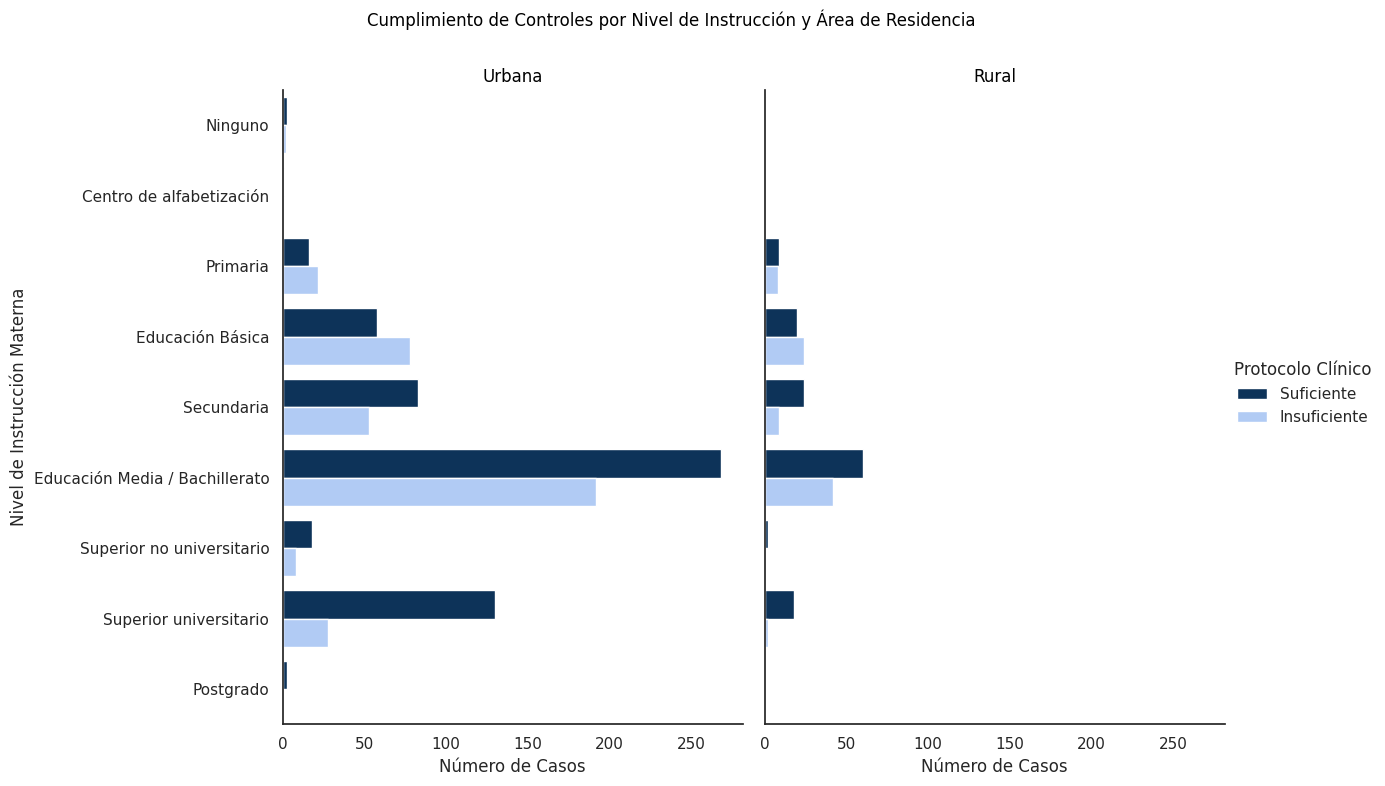

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('dataset__limpio.csv')


def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)


orden_instruccion = [
    'Ninguno',
    'Centro de alfabetización',
    'Primaria',
    'Educación Básica',
    'Secundaria',
    'Educación Media / Bachillerato',
    'Superior no universitario',
    'Superior universitario',
    'Postgrado'
]


sns.set_style("white")
g = sns.catplot(
    data=df,
    y='niv_inst',
    hue='control_clinico',
    col='area_res',
    kind='count',
    order=orden_instruccion,
    palette=['#003366', '#A6C8FF'],
    height=8,
    aspect=0.8
)


g.set_titles("{col_name}", size=14, color='black', fontweight='normal')
g.set_axis_labels("Número de Casos", "Nivel de Instrucción Materna", fontsize=12)
g._legend.set_title("Protocolo Clínico")


for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontweight='normal', color='black')

plt.subplots_adjust(top=0.88)
g.fig.suptitle('Cumplimiento de Controles por Nivel de Instrucción y Área de Residencia',
               fontsize=12, color='black', fontweight='normal')

plt.show()

La educación materna parece ser un factor protector en ambos entornos, ya que niveles más altos de instrucción se correlacionan con un mayor cumplimiento del protocolo de controles prenatales.

Brecha en Calidad/Acceso: A pesar de que el análisis Chi-cuadrado previo no mostró una diferencia significativa general en la suficiencia de controles entre áreas rurales y urbanas, este gráfico detallado revela que la combinación de baja instrucción y residencia rural puede agravar la vulnerabilidad. Aunque las madres rurales asisten a controles en una proporción similar a las urbanas en términos generales, la calidad de la atención o la capacidad de respuesta del sistema de salud ante la educación específica de las madres en las zonas rurales podría ser deficiente.

Este análisis es crucial para el modelado de clustering, ya que permite identificar subgrupos específicos de vulnerabilidad (por ejemplo, madres rurales con educación básica) que podrían requerir intervenciones dirigidas no solo a aumentar la cantidad de controles, sino también a mejorar la comunicación, la calidad de la atención y la accesibilidad de los servicios de salud adaptados a sus perfiles socio-educativos y geográficos.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


df = pd.read_csv('dataset__limpio.csv')


def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)


tabla = pd.crosstab(df['niv_inst'], df['control_clinico'])


chi2, p, dof, ex = chi2_contingency(tabla)


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

v_cramer = cramers_v(df['niv_inst'], df['control_clinico'])

print(f"--- Análisis de Correlación (Asociación) ---")
print(f"Valor p (Significancia): {p:.4e}")
print(f"V de Cramer (Fuerza de asociación): {v_cramer:.4f}")


if p < 0.05:
    print("\nConclusión: Existe una correlación estadísticamente significativa.")
    if v_cramer < 0.1: interpretacion = "muy débil"
    elif v_cramer < 0.3: interpretacion = "moderada"
    else: interpretacion = "fuerte"
    print(f"La fuerza de la relación es {interpretacion}.")
else:
    print("\nConclusión: No existe una correlación significativa entre las variables.")

--- Análisis de Correlación (Asociación) ---
Valor p (Significancia): 3.7607e-12
V de Cramer (Fuerza de asociación): 0.2300

Conclusión: Existe una correlación estadísticamente significativa.
La fuerza de la relación es moderada.


Al realizar un análisis de correlación, se evidencia que el nivel de instrucción materna sí influye en la adherencia al protocolo de controles prenatales, aunque la relación no es extremadamente fuerte. Esto apoya la idea de que la educación es un factor relevante en el acceso y aprovechamiento de la atención de salud durante el embarazo.

**Análisis de Disparidad Étnica en el Seguimiento Prenatal**

El sistema de salud debe garantizar la equidad no solo geográfica, sino también intercultural. Mediante este análisis, se evalúa si la autoidentificación étnica de la madre influye en el cumplimiento del protocolo clínico de controles prenatales.

Identificar si ciertos grupos étnicos presentan sistemáticamente niveles de insuficiencia más altos es crucial para determinar si las estrategias de prevención de mortalidad fetal fallan por falta de pertinencia cultural, o si el sistema de salud no logra integrar de manera efectiva a poblaciones históricamente vulnerabilizadas. Este hallazgo permitirá al modelo de clustering identificar si la etnia actúa como un factor de riesgo aislado o si se potencia al interactuar con el nivel de instrucción y el territorio.

<Figure size 1200x700 with 0 Axes>

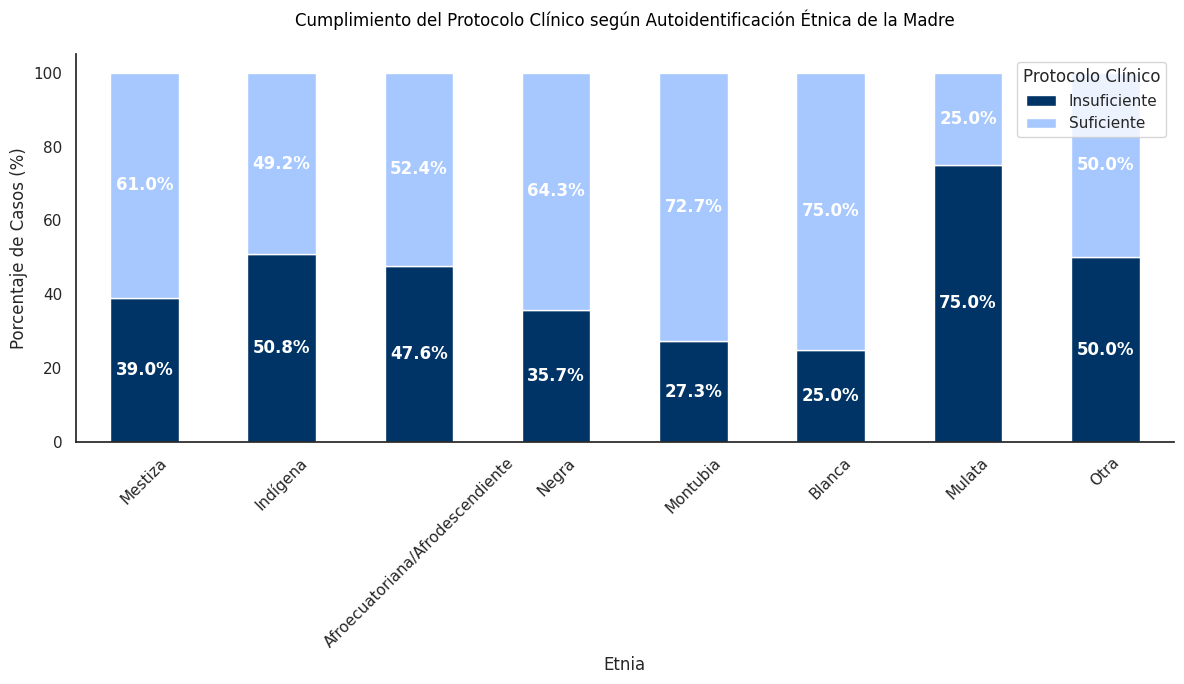

--- Resultados Estadísticos ---
Valor p (Chi-cuadrado): 3.9209e-01


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


df = pd.read_csv('dataset__limpio.csv')


def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)


tabla_etnia = pd.crosstab(df['etnia'], df['control_clinico'])
orden_etnia = tabla_etnia.sum(axis=1).sort_values(ascending=False).index
tabla_etnia = tabla_etnia.reindex(orden_etnia)


chi2, p, dof, ex = chi2_contingency(tabla_etnia)


plt.figure(figsize=(12, 7))
tabla_pct = tabla_etnia.div(tabla_etnia.sum(1), axis=0) * 100


azul_fuerte = "#003366"
azul_claro = "#A6C8FF"

ax = tabla_pct.plot(kind='bar', stacked=True, color=[azul_fuerte, azul_claro], figsize=(12, 7), rot=45)


plt.title('Cumplimiento del Protocolo Clínico según Autoidentificación Étnica de la Madre',
          fontsize=12, fontweight='normal', color='black', pad=20)

plt.ylabel('Porcentaje de Casos (%)', fontsize=12)
plt.xlabel('Etnia', fontsize=12)
plt.legend(title='Protocolo Clínico', labels=['Insuficiente', 'Suficiente'], loc='upper right')


for p_bar in ax.patches:
    width, height = p_bar.get_width(), p_bar.get_height()
    x, y = p_bar.get_xy()
    if height > 5:
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center',
                color='white' if height > 40 else 'white', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print(f"--- Resultados Estadísticos ---")
print(f"Valor p (Chi-cuadrado): {p:.4e}")

El análisis de la autoidentificación étnica de la madre frente al cumplimiento del protocolo clínico revela una homogeneidad relativa en la desprotección. Si bien se observan variaciones visuales, donde la población indígena y afrodescendiente presenta niveles de insuficiencia que rondan el 51% y 48% respectivamente, la prueba de Chi-cuadrado ($p = 0.3921$) determina que estas diferencias no son estadísticamente significativas.

Este hallazgo sugiere que la vulnerabilidad sistémica en el control prenatal es un fenómeno que atraviesa las fronteras étnicas en Ecuador. La barrera al acceso parece responder más a la interacción de múltiples factores (educación, calidad del servicio, logística) que a una exclusión basada exclusivamente en la identidad étnica. Para el modelo de clustering, esto implica que la etnia no debe ser analizada de forma aislada, sino como parte de un perfil de riesgo interseccional.

**Análisis de Desplazamiento Intercantonal y Vulnerabilidad por Área**

Para detectar fallas en la red de salud a nivel local, se ha definido la variable 'Desplazamiento Cantonal', que identifica si el deceso ocurrió en un cantón distinto al de residencia. A diferencia del análisis provincial, este enfoque de micro-territorio permite visualizar la dependencia de los cantones periféricos hacia los nodos urbanos de salud.

Se emplea una Correlación de Punto Biserial para determinar si estos traslados afectan a embarazos de mayor edad gestacional, segmentando los resultados por Área de Residencia. Este análisis es el núcleo de la hipótesis de 'Muerte en Tránsito': si las madres de áreas rurales o urbanas marginales deben abandonar su cantón para buscar atención en etapas avanzadas del embarazo, estamos ante una evidencia irrefutable de inequidad en la distribución de la capacidad resolutiva obstétrica del país.

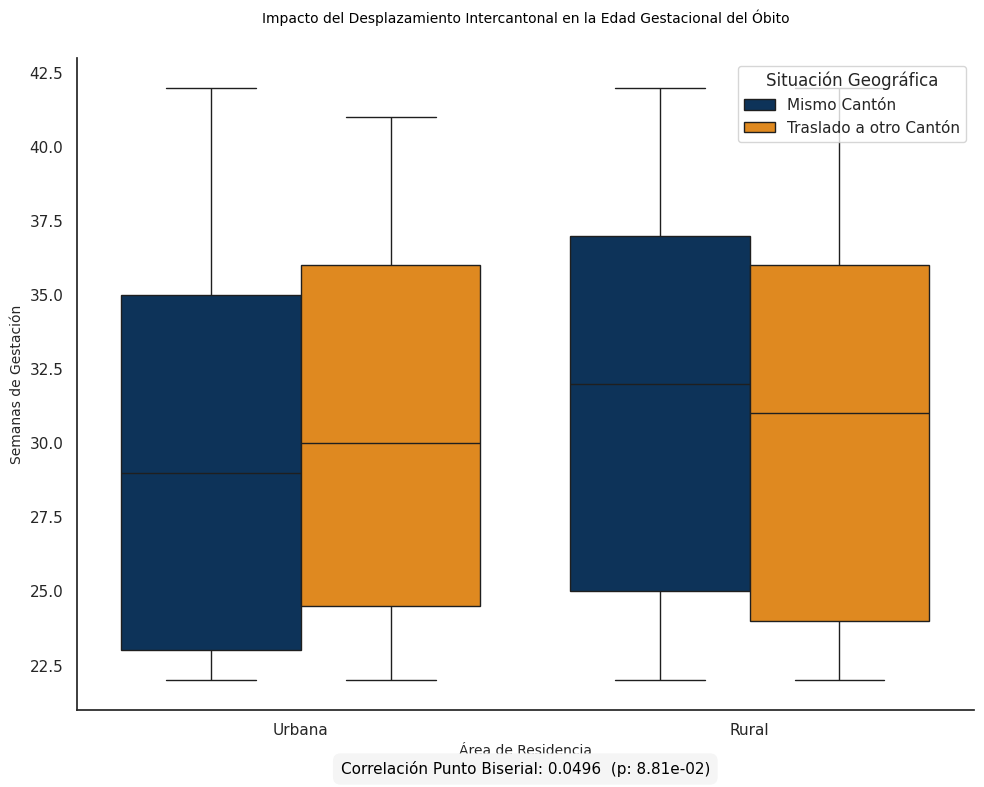

--- Porcentaje de Desplazamiento por Área ---
area_res
Rural     34.38914
Urbana    20.66459
Name: desp_cantonal, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr


df = pd.read_csv('dataset__limpio.csv')


df['Situacion_Geografica'] = (df['cant_res'] != df['cant_fall']).map({
    True: 'Traslado a otro Cantón',
    False: 'Mismo Cantón'
})

df['desp_cantonal'] = (df['cant_res'] != df['cant_fall']).astype(int)


corr_gen, p_gen = pointbiserialr(df['desp_cantonal'], df['sem_gest'])


plt.figure(figsize=(10, 8))


colores_dict = {'Mismo Cantón': "#003366", 'Traslado a otro Cantón': "#FF8C00"}

ax = sns.boxplot(
    x='area_res',
    y='sem_gest',
    hue='Situacion_Geografica',
    data=df,
    palette=colores_dict,
    hue_order=['Mismo Cantón', 'Traslado a otro Cantón']
)


plt.title('Impacto del Desplazamiento Intercantonal en la Edad Gestacional del Óbito',
          fontsize=10, fontweight='normal', color='black', pad=25)

plt.xlabel('Área de Residencia', fontsize=10)
plt.ylabel('Semanas de Gestación', fontsize=10)


plt.legend(title='Situación Geográfica', loc='upper right')


plt.text(0.5, df['sem_gest'].min() - 3,
         f'Correlación Punto Biserial: {corr_gen:.4f}  (p: {p_gen:.2e})',
         ha='center', va='center', fontsize=11, color='black',
         bbox=dict(facecolor='#F5F5F5', edgecolor='none', boxstyle='round,pad=0.5'))

sns.despine()
plt.tight_layout()
plt.show()


print("--- Porcentaje de Desplazamiento por Área ---")
print(df.groupby('area_res')['desp_cantonal'].mean() * 100)

In [ ]:

tabla_desp = pd.crosstab(df['area_res'], df['desp_cantonal'])


tabla_porcentajes = tabla_desp.div(tabla_desp.sum(axis=1), axis=0) * 100


tabla_porcentajes.columns = ['Mismo Cantón (%)', 'Traslado a otro Cantón (%)']

print("--- Análisis de Desplazamiento Forzado por Área ---")
print(tabla_porcentajes.round(2)) # 2 decimales

--- Análisis de Desplazamiento Forzado por Área ---
          Mismo Cantón (%)  Traslado a otro Cantón (%)
area_res                                              
Rural                65.61                       34.39
Urbana               79.34                       20.66


Los resultados demuestran que el desplazamiento no afecta de manera equitativa a la población, sino que está fuertemente condicionado por el entorno geográfico. Mientras que en el área urbana el 20.66% de los óbitos fetales ocurrieron tras un traslado fuera del cantón de origen, en el área rural esta cifra asciende al 34.39%.Esta diferencia de casi 14 puntos porcentuales sugiere que las zonas rurales funcionan bajo una lógica de dependencia sanitaria, donde la falta de equipamiento o personal especializado obliga a una de cada tres madres rurales a buscar atención en nodos urbanos de mayor complejidad.Estadísticamente, la Correlación de Punto Biserial ($r = 0.0496; p = 0.0881$) indica que el desplazamiento ocurre de forma transversal a lo largo de diversas etapas del embarazo. Sin embargo, la observación de medianas de edad gestacional más elevadas en los casos de traslado sugiere que el sistema está movilizando a madres con fetos viables (gestaciones avanzadas). Este patrón es característico de una respuesta reactiva ante la emergencia: el traslado no se realiza como una medida preventiva planificada, sino como un recurso de última instancia cuando el compromiso fetal es inminente y la infraestructura local se ve superada.

En conclusión, el desplazamiento intercantonal actúa como un marcador de vulnerabilidad logística, donde el riesgo de óbito fetal se ve agravado por el tiempo y la distancia recorridos, especialmente para la población rural, consolidando la hipótesis de una red de salud con nudos críticos de desatención en la periferia.

**Resumen General del Análisis Exploratorio (EDA)**

El análisis integral de las defunciones fetales en el país revela que la mortalidad no es un evento aleatorio, sino el resultado de una convergencia de determinantes sociales, educativos y geográficos.

A continuación, se sintetizan los hallazgos que fundamentarán el modelo de clustering:

**1. El Factor Educativo como Determinante de Acceso**

El nivel de instrucción de la madre es la variable con mayor peso estadístico en el cumplimiento del protocolo clínico. Existe una brecha significativa donde las madres con instrucción básica presentan sistemáticamente menos controles prenatales. Esto confirma que la educación actúa como un habilitador crítico para la navegación efectiva dentro del sistema de salud.

**2. Vulnerabilidad Logística y el Riesgo Rural**

El análisis territorial identifica al área rural como la zona de mayor fragilidad logística. Con un 34.39% de desplazamientos intercantonales, queda en evidencia que una de cada tres madres rurales debe abandonar su territorio para buscar atención.Este fenómeno de "Muerte en Tránsito" sugiere que los centros de salud rurales no poseen la capacidad resolutiva necesaria para gestionar complicaciones, funcionando únicamente como puntos de derivación.

**3. Falla Sistémica Transversal (Protocolo Clínico)**

El sistema de salud presenta una deficiencia generalizada en la cobertura. Con aproximadamente un 40% de casos que no cumplen con el mínimo de controles prenatales, se concluye que la desprotección es un problema estructural del sistema que afecta a todos los grupos por igual, sin sesgos étnicos estadísticamente significativos.

**4. Micro-fragmentación de la Red de Salud**

Al analizar el origen del desplazamiento a nivel de parroquia y cantón, se identifican "zonas de silencio" o desiertos de salud. El hecho de que los traslados ocurran frecuentemente en etapas avanzadas de gestación indica que el desplazamiento es reactivo y no preventivo, ocurriendo cuando el riesgo fetal ya es inminente.

**Hallazgos para el modelo:**

**1. Dimensión Socio-Educativa:**

Hallazgo Clave: Baja instrucción = Menos controles

Relevancia para el Modelo: Define el perfil de vulnerabilidad social.


**2. Dimensión Geográfica:**

Hallazgo Clave: Alta tasa de salida en áreas rurales

Relevancia para el Modelo: Variable clave para el Riesgo de Distancia.

**3. Dimensión Intercultural:**

Hallazgo Clave: Sin disparidad significativa

Relevancia para el Modelo: La etnia será una variable descriptiva, no un predictor aislado.

**4. Dimensión Clínica**

Hallazgo Clave: Insuficiencia generalizada

Relevancia para el Modelo: Indica fallas en la captación temprana del embarazo.

---



**Arquitectura de Modelado Propuesta**

La arquitectura de este proyecto se fundamenta en un flujo de procesamiento de tres fases, diseñado para transformar datos administrativos en conocimiento accionable sobre la prevenibilidad de la mortalidad fetal.

Esta arquitectura transita desde la explicación estadística hacia la predicción proactiva, garantizando la integridad metodológica mediante la mitigación del Data Leakage.

**Fase 1: Clustering No Supervisado y Perfilado Post-Hoc**

Para descubrir patrones de riesgo que no son evidentes mediante el análisis lineal, se utilizarán técnicas de agrupamiento y minería de reglas.

**Clustering con K-Means**  Se segmentará a las madres en grupos de vulnerabilidad

**Fase 2: Modelado Predictivo y Clasificación de Prevenibilidad**

La fase final consiste en el despliegue de modelos de aprendizaje supervisado para clasificar los casos en Clase 1 (Potencialmente Prevenible) o Clase 0 (Inevitable/Inviabilidad Biológica).

**Algoritmos de Ensamble:** Se evaluarán **Random Forest, CatBoost y Regresión Logística** por medio de una matriz de confusión.

**Evaluación y Calibración:** Los modelos se evaluarán mediante una **Matriz de Confusión**, priorizando la métrica de Sensibilidad (Recall) y el F1-Score.

El objetivo es minimizar los falsos negativos (casos prevenibles no detectados por el modelo), garantizando que la herramienta sea una alerta temprana efectiva para la gestión de salud pública.

**Arquitectura de Datos para el Modelo de Prevenibilidad**

Esta tabla separa claramente qué información entra al cerebro de la IA (Features) y qué se está tratando de predecir (Target), justificando la exclusión de las variables que podrían causar data leakage.

In [ ]:
import pandas as pd
from google.colab import data_table


arquitectura_dict = {
    "Dimensión": [
        "Socio-Cultural", "Socio-Cultural", "Demográfica", "Demográfica",
        "Socio-Económica", "Geográfica", "Geográfica", "Geográfica",
        "Reproductiva", "Temporal", "TARGET"
    ],
    "Variable (Feature)": [
        "niv_inst", "sabe_leer", "edad_mad", "etnia",
        "est_civil", "prov_res", "cant_res", "area_res",
        "hij_viv / hij_nacm", "mes_fall / anio_fall", "PREVENIBLE (y)"
    ],
    "Tipo de Dato": [
        "Categórica", "Categórica", "Numérica", "Categórica",
        "Categórica", "Categórica", "Categórica", "Categórica",
        "Numérica", "Categórica", "Binaria (0/1)"
    ],
    "Rol en el Modelo": [
        "Predictor (X)", "Predictor (X)", "Predictor (X)", "Predictor (X)",
        "Predictor (X)", "Predictor (X)", "Predictor (X)", "Predictor (X)",
        "Predictor (X)", "Predictor (X)", "Etiqueta (Target)"
    ],
    "Justificación Metodológica (Anti-Leakage)": [
        "Principal predictor de comportamiento y acceso detectado en EDA.",
        "Define la capacidad de navegación en protocolos de salud.",
        "Identifica riesgo biológico sin revelar el desenlace fetal.",
        "Observa barreras de acceso vinculadas a la interculturalidad.",
        "Proxy de la red de apoyo y estabilidad del entorno.",
        "Identifica inequidades regionales de recursos de salud.",
        "Aprende la capacidad resolutiva histórica de cada territorio.",
        "Define infraestructura base y cercanía a especialidades.",
        "Antecedentes preexistentes al embarazo actual.",
        "Captura estacionalidad o cambios en políticas anuales.",
        "Calculada fuera del entrenamiento mediante lógica multidimensional."
    ]
}


df_arquitectura = pd.DataFrame(arquitectura_dict)
tabla_estilizada = df_arquitectura.style.hide(axis='index')

print("TABLA: ARQUITECTURA DE DATOS PARA EL MODELO DE PREVENIBILIDAD")
tabla_estilizada

TABLA: ARQUITECTURA DE DATOS PARA EL MODELO DE PREVENIBILIDAD


Dimensión,Variable (Feature),Tipo de Dato,Rol en el Modelo,Justificación Metodológica (Anti-Leakage)
Socio-Cultural,niv_inst,Categórica,Predictor (X),Principal predictor de comportamiento y acceso detectado en EDA.
Socio-Cultural,sabe_leer,Categórica,Predictor (X),Define la capacidad de navegación en protocolos de salud.
Demográfica,edad_mad,Numérica,Predictor (X),Identifica riesgo biológico sin revelar el desenlace fetal.
Demográfica,etnia,Categórica,Predictor (X),Observa barreras de acceso vinculadas a la interculturalidad.
Socio-Económica,est_civil,Categórica,Predictor (X),Proxy de la red de apoyo y estabilidad del entorno.
Geográfica,prov_res,Categórica,Predictor (X),Identifica inequidades regionales de recursos de salud.
Geográfica,cant_res,Categórica,Predictor (X),Aprende la capacidad resolutiva histórica de cada territorio.
Geográfica,area_res,Categórica,Predictor (X),Define infraestructura base y cercanía a especialidades.
Reproductiva,hij_viv / hij_nacm,Numérica,Predictor (X),Antecedentes preexistentes al embarazo actual.
Temporal,mes_fall / anio_fall,Categórica,Predictor (X),Captura estacionalidad o cambios en políticas anuales.


**Creación de la Variable Objetivo**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files


lista_incompatibles = [
    "Agenesia renal, sin otra especificación", "Atresia de los agujeros de magendie y de luschka",
    "Otras malformaciones congénitas de los tabiques cardíacos", "Malformación congénita de miembro(s), no especificada",
    "Anencefalia", "Malformación congénita, no especificada", "Anomalía cromosómica, no especificada",
    "Ausencia, atresia y estenosis congénita del duodeno", "Hidrocéfalo congénito, no especificado",
    "Otras malformaciones congénitas, especificadas", "Malformación congénita del corazón, no especificada",
    "Encefalocele, no especificado", "Encefalocele frontal", "Coartación de la aorta",
    "Espina bífida, no especificada", "Otras malformaciones congénitas del corazón, especificadas",
    "Atresia del esófago sin mención de fístula", "Síndrome de potter", "Microcefalia",
    "Gastrosquisis", "Osteocondrodisplasia, no especificada", "Riñón poliquístico, tipo no especificado",
    "Trisomía 18, por translocación"
]


def clasificar_prevenibilidad(df):

    df['estado_viabilidad'] = np.where(
        (df['sem_gest'] >= 22) & (df['peso'] >= 500) & (df['talla'] >= 25) &
        (~df['causa_fetal'].isin(lista_incompatibles)),
        'Viable', 'Inviable'
    )


    def evaluar_gestion(row):
        sem, ctrl = row['sem_gest'], row['con_pren']
        if pd.isna(sem) or pd.isna(ctrl): return 0


        if sem <= 12: return 1 if ctrl < 1 else 0
        elif 13 <= sem <= 27: return 1 if ctrl < 3 else 0
        elif sem >= 28: return 1 if ctrl < 5 else 0
        return 0

    df['fallo_gestion'] = df.apply(evaluar_gestion, axis=1)


    df['fallo_territorial'] = (df['cant_res'] != df['cant_fall']).astype(int)


    df['prevenible'] = np.where(
        (df['estado_viabilidad'] == 'Viable') &
        ((df['fallo_gestion'] == 1) | (df['fallo_territorial'] == 1)),
        1, 0
    )
    return df


df = clasificar_prevenibilidad(df)

if 'fallo_gestion_individual' in df.columns:
    df = df.drop(columns=['fallo_gestion_individual'])


nombre_archivo = 'dataset_final_etiquetado.csv'
df.to_csv(nombre_archivo, index=False)

print(f"✅ Proceso terminado. Archivo '{nombre_archivo}' con n={len(df)} registros.")
files.download(nombre_archivo)

✅ Proceso terminado. Archivo 'dataset_final_etiquetado.csv' con n=1184 registros.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Para clasificar un caso de defunción fetal como **'Potencialmente Prevenible'**   (Clase 1), se consideran tres grupos de características principales, que deben cumplirse de manera combinada, según la lógica aplicada en el código:

Un óbito fetal se considera Potencialmente Prevenible (Clase 1) si:

**Hay Viabilidad Biológica (Condición Obligatoria):**

Las semanas de gestación (sem_gest) son mayores o iguales a 22.

El peso del feto (peso) es mayor o igual a 500 gramos.

La talla del feto (talla) es mayor o igual a 25 centímetros.

La causa fetal (causa_fetal) NO está en una lista de malformaciones congénitas o condiciones incompatibles con la vida previamente definidas (Lista OMS)

**Resumen:** El feto tenía las condiciones biológicas mínimas para haber sido viable, y su muerte no fue por una causa biológica inherentemente incompatible con la vida.

Y

**Existe un Fallo en la Gestión de Atención Individual O un Fallo Territorial:**

Fallo de Gestión (Suficiencia Dinámica de Controles Prenatales): Esto se evalúa según el número de controles prenatales (con_pren) en relación con la semana de gestación (sem_gest) en la que ocurrió el óbito:

Si el óbito ocurrió en el 1er Trimestre (≤ 12 semanas): La madre tuvo menos de 1 control prenatal.

Si el óbito ocurrió en el 2do Trimestre (13 - 27 semanas): La madre tuvo menos de 3 controles prenatales.

Si el óbito ocurrió en el 3er Trimestre (≥ 28 semanas): La madre tuvo menos de 5 controles prenatales.

**Resumen:** La madre no cumplió con el protocolo mínimo de controles prenatales esperados para la edad gestacional del feto.

O

**Fallo Territorial (Desplazamiento Intercantonal):**

El cantón de residencia de la madre (cant_res) es diferente al cantón de fallecimiento (cant_fall) del feto.

**Resumen:**  El evento fatal ocurrió en un cantón distinto al de residencia de la madre, lo que sugiere una necesidad de traslado que podría indicar falta de capacidad resolutiva local.

Por lo tanto, para que un caso sea **Potencialmente Prevenible**, debe haber una base de viabilidad biológica Y una falla en el sistema de atención (ya sea en el seguimiento individual de la madre o en la provisión de servicios de salud en su lugar de origen que obligó a un traslado).

**Distribución de prevenibilidad**

--- DISTRIBUCIÓN DE PREVENIBILIDAD ---
                Total  Porcentaje (%)
Inevitable (0)    589       49.746622
Prevenible (1)    595       50.253378


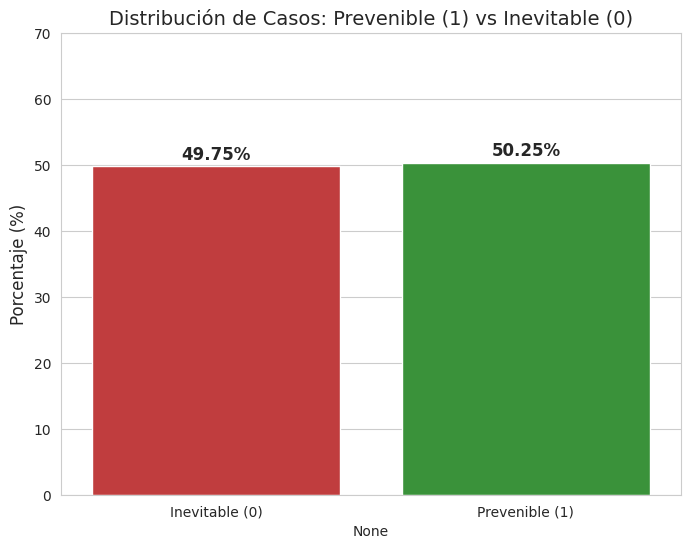

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


conteo = df['prevenible'].value_counts().sort_index()
porcentaje = df['prevenible'].value_counts(normalize=True).sort_index() * 100

df_distribucion = pd.DataFrame({'Total': conteo, 'Porcentaje (%)': porcentaje})
df_distribucion.index = ['Inevitable (0)', 'Prevenible (1)']

print("--- DISTRIBUCIÓN DE PREVENIBILIDAD ---")
print(df_distribucion)


plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x=df_distribucion.index,
    y=df_distribucion['Porcentaje (%)'],
    hue=df_distribucion.index,
    palette=['#d62728', '#2ca02c'],
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Distribución de Casos: Prevenible (1) vs Inevitable (0)', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.ylim(0, 70)
plt.show()

La distribución de la variable objetivo tras la aplicación de la lógica multidimensional muestra un equilibrio óptimo en los datos ($n=1,184$).

Se observa que el **50.25%**   de las muertes fetales fueron clasificadas como **potencialmente prevenibles**, mientras que el **49.75%** se categorizaron como **inevitables**.

Esta paridad en la distribución de las clases garantiza la ausencia de sesgos de aprendizaje durante el entrenamiento del modelo, permitiendo una capacidad de generalización equitativa para identificar factores de riesgo y factores protectores en ambos grupos.

## **Fase 1: Clustering No Supervisado y Perfilado Post-Hoc**

Se busca determinar si la variable objetivo diseñada (prevenible) emerge de la estructura natural de los datos al integrar dimensiones biológicas, de gestión individual y de gestión territorial.

Se aplica el algoritmo **K-Means**. Aquí se incluyen las variables que componen la lógica de ingeniería para verificar si el algoritmo descubre grupos que coincidan con los criterios de prevención. Se transforma la variable causa_fetal en un indicador clínico binario para permitir el procesamiento matemático.

**Determinación del Número Óptimo de Clústeres**

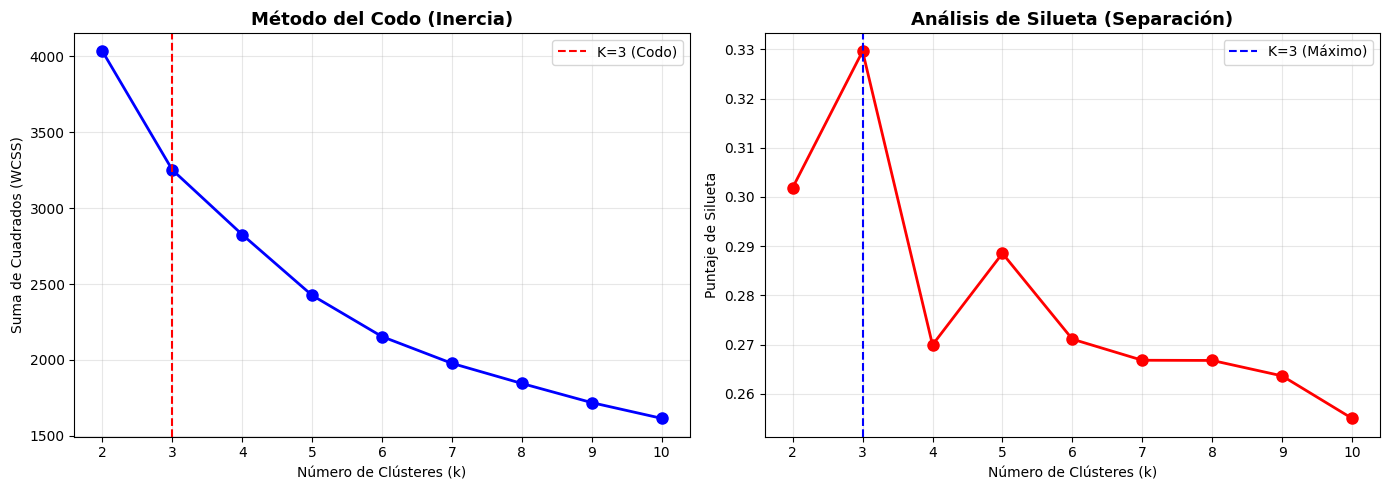

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


vars_clustering = ['edad_mad', 'sem_gest', 'peso', 'con_pren', 'fallo_territorial']
X_clustering = df[vars_clustering]


scaler = StandardScaler()
X_fit = scaler.fit_transform(X_clustering)


inercia = []
siluetas = []
K = range(2, 11)

for k in K:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X_fit)
    inercia.append(kmeans_model.inertia_)
    siluetas.append(silhouette_score(X_fit, labels))


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(K, inercia, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K=3 (Codo)')
plt.title('Método del Codo (Inercia)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Suma de Cuadrados (WCSS)')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(K, siluetas, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=3, color='blue', linestyle='--', label='K=3 (Máximo)')
plt.title('Análisis de Silueta (Separación)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Puntaje de Silueta')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Con el fin de determinar de manera objetiva la configuración de clústeres más representativa para los datos de mortalidad fetal, se procedió a realizar una doble validación técnica mediante el **Método del Codo (Inercia)** y el **Coeficiente de Silueta (Silhouette Score)**.

Como se observa en los gráficos, el método del codo presenta un punto de inflexión prominente en $k=3$, indicando que a partir de este valor la ganancia en la reducción de la varianza intraclase disminuye significativamente. Complementariamente, el análisis de silueta alcanza un valor máximo local en la misma posición ($k=3$), lo que confirma que esta estructura no solo es compacta internamente, sino que maximiza la distancia interclase.

# **Verificación de Variable Objetivo Construída vs. Clusterización K-Means**

**Sin ponderación X2 Ratio Controles / Semanas y discriminando las causas de muerte fetal incompatibles con la vida, se usa Z-Score Standardization**

* etnia
* est_civil
* niv_inst
* edad_mad
* hij_nacm
* peso
* talla
* con_pren / sem_gest  **--> X1**
* cant_res **diferente** cant_fall
* causa_fetal **diferente** a causas incombatibles con la vida

In [ ]:
import pandas as pd
import numpy as np
import io
import base64
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import ipywidgets as widgets
from IPython.display import display, HTML


uploader = widgets.FileUpload(accept='.csv', multiple=False)
print("Sube tu archivo para perfilamiento (Ajuste por Causa Fetal + Sin ponderación):")
display(uploader)

def crear_boton_descarga(df_final):
    """Genera un botón para descargar el CSV con las etiquetas ajustadas"""
    csv = df_final.to_csv(index=False)
    b64 = base64.b64encode(csv.encode()).decode()
    payload = f"data:text/csv;base64,{b64}"
    html = f'''
    <a href="{payload}" download="perfilamiento_ajustado.csv">
        <button style="background-color: #2E4053; color: white; padding: 12px 24px;
        border: none; border-radius: 8px; cursor: pointer; font-size: 14px; font-weight: bold;">
            📥 Descargar Dataset (Ajustado)
        </button>
    </a>
    '''
    display(HTML(html))

def ejecutar_perfilamiento_sin_x3(b):
    try:

        input_file = list(uploader.value.values())[0]
        df = pd.read_csv(io.BytesIO(input_file['content']))
        print("✅ Archivo cargado. Procesando...")


        df['desplazamiento'] = (df['cant_res'].astype(str).str.strip().str.upper() !=
                                df['cant_fall'].astype(str).str.strip().str.upper()).astype(int)


        cols_numericas = ['edad_mad', 'hij_nacm', 'peso', 'talla', 'con_pren', 'sem_gest']
        for col in cols_numericas:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)


        df['ratio_prenatal'] = df['con_pren'] / df['sem_gest'].replace(0, 1)


        features = ['etnia', 'est_civil', 'niv_inst', 'edad_mad', 'hij_nacm', 'peso', 'talla', 'ratio_prenatal', 'desplazamiento']
        X = df[features].copy()


        le = LabelEncoder()
        for col in ['etnia', 'est_civil', 'niv_inst']:
            X[col] = le.fit_transform(X[col].astype(str))


        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)


        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels_raw = kmeans.fit_predict(X_scaled)


        df['perfil_cluster'] = np.where(labels_raw == 0, 1, 0)


        causas_cluster_0 = [
            "Agenesia renal, sin otra especificación", "Atresia de los agujeros de magendie y de luschka",
            "Otras malformaciones congénitas de los tabiques cardíacos", "Malformación congénita de miembro(s), no especificada",
            "Anencefalia", "Malformación congénita, no especificada", "Anomalía cromosómica, no especificada",
            "Ausencia, atresia y estenosis congénita del duodeno", "Hidrocéfalo congénito, no especificado",
            "Otras malformaciones congénitas, especificadas", "Malformación congénita del corazón, no especificada",
            "Encefalocele, no especificado", "Encefalocele frontal", "Coartación de la aorta",
            "Espina bífida, no especificada", "Otras malformaciones congénitas del corazón, especificadas",
            "Atresia del esófago sin mención de fístula", "Síndrome de potter", "Microcefalia",
            "Gastrosquisis", "Osteocondrodisplasia, no especificada", "Riñón poliquístico, tipo no especificado",
            "Trisomía 18, por translocación"
        ]

        if 'causa_fetal' in df.columns:

            mask_ajuste = df['causa_fetal'].str.strip().isin(causas_cluster_0)
            df.loc[mask_ajuste, 'perfil_cluster'] = 0
            print(f" Se han reasignado {mask_ajuste.sum()} registros al Cluster 0 por causa médica específica.")


        print("\n" + "="*75)
        print("RESUMEN FINAL (ALGORITMO + REGLAS MÉDICAS)")
        print("="*75)

        for i in [0, 1]:
            sub = df[df['perfil_cluster'] == i]
            print(f"\n📍 GRUPO {i} (N = {len(sub)} registros)")
            print(f"   - Tasa de Desplazamiento: {sub['desplazamiento'].mean()*100:.1f}%")
            print(f"   - Ratio Prenatal (Promedio): {sub['ratio_prenatal'].mean():.4f}")
            print(f"   - Edad Madre (Promedio): {sub['edad_mad'].mean():.1f} años")
            print(f"   - Peso RN (Promedio): {sub['peso'].mean():.0f}g")
            print("-" * 60)

        print("\n✅ Perfilamiento finalizado exitosamente.")
        crear_boton_descarga(df)

    except Exception as e:
        print(f"❌ Error durante la ejecución: {e}")


btn = widgets.Button(description="Generar Clústeres con Ajuste", button_style='primary', layout={'width': '350px'})
btn.on_click(ejecutar_perfilamiento_sin_x3)
display(btn)

Sube tu archivo para perfilamiento (Ajuste por Causa Fetal + Sin ponderación):


FileUpload(value={}, accept='.csv', description='Upload')

Button(button_style='primary', description='Generar Clústeres con Ajuste', layout=Layout(width='350px'), style…

✅ Archivo cargado. Procesando...
⚠️ Se han reasignado 38 registros al Cluster 0 por causa médica específica.

RESUMEN FINAL (ALGORITMO + REGLAS MÉDICAS)

📍 GRUPO 0 (N = 526 registros)
   - Tasa de Desplazamiento: 24.7%
   - Ratio Prenatal (Promedio): 0.1504
   - Edad Madre (Promedio): 27.4 años
   - Peso RN (Promedio): 2475g
------------------------------------------------------------

📍 GRUPO 1 (N = 658 registros)
   - Tasa de Desplazamiento: 22.0%
   - Ratio Prenatal (Promedio): 0.1444
   - Edad Madre (Promedio): 26.9 años
   - Peso RN (Promedio): 830g
------------------------------------------------------------

✅ Perfilamiento finalizado exitosamente.


Sube tu archivo para validación (Leyenda Mejorada):


FileUpload(value={}, accept='.csv', description='Upload')

Button(button_style='success', description='Generar Reporte Visual', layout=Layout(width='350px'), style=Butto…

/tmp/ipykernel_6389/1848026490.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Clúster 0', 'Clúster 1'])


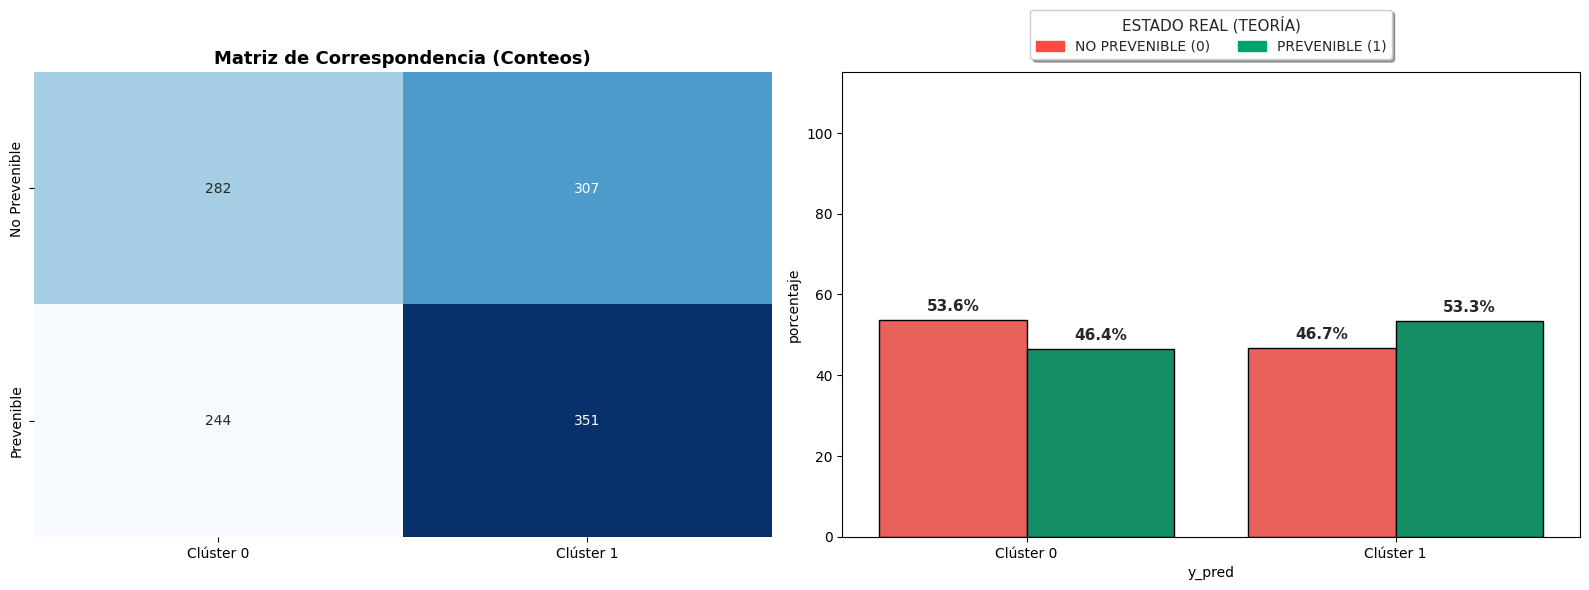


✅ Análisis completado. Casos válidos: 1184 | ARI: 0.0040


In [ ]:
import pandas as pd
import numpy as np
import io
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
import ipywidgets as widgets
from IPython.display import display
import matplotlib.patches as mpatches


uploader = widgets.FileUpload(accept='.csv', multiple=False)
print("Sube tu archivo para validación (Leyenda Mejorada):")
display(uploader)

def ejecutar_validacion_completa(b):
    try:
        input_file = list(uploader.value.values())[0]
        content_raw = input_file['content']


        try:
            df = pd.read_csv(io.BytesIO(content_raw), sep=None, engine='python', encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(io.BytesIO(content_raw), sep=None, engine='python', encoding='latin-1')

        df.columns = df.columns.str.strip()


        df['y_pred'] = pd.to_numeric(df['perfil_cluster'], errors='coerce')
        df['y_true'] = pd.to_numeric(df['prevenible'], errors='coerce')
        df_limpio = df.dropna(subset=['y_pred', 'y_true'])


        y_true = df_limpio['y_true'].astype(int)
        y_pred = df_limpio['y_pred'].astype(int)
        matrix = confusion_matrix(y_true, y_pred)
        ari = adjusted_rand_score(y_true, y_pred)
        nmi = normalized_mutual_info_score(y_true, y_pred)


        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        sns.set_style("whitegrid")


        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax1,
                    xticklabels=['Clúster 0', 'Clúster 1'],
                    yticklabels=['No Prevenible', 'Prevenible'], cbar=False)
        ax1.set_title('Matriz de Correspondencia (Conteos)', fontsize=13, fontweight='bold')


        df_plot = df_limpio.groupby(['y_pred', 'y_true']).size().reset_index(name='cantidad')
        total_por_cluster = df_limpio.groupby('y_pred').size()
        df_plot['porcentaje'] = df_plot.apply(
            lambda x: (x['cantidad'] / total_por_cluster[x['y_pred']]) * 100, axis=1
        )


        color_no = "#FF4B44"
        color_si = "#00A36C"


        sns.barplot(data=df_plot, x='y_pred', y='porcentaje', hue='y_true',
                    palette={0: color_no, 1: color_si}, ax=ax2, edgecolor="black")


        patch_no = mpatches.Patch(color=color_no, label='NO PREVENIBLE (0)')
        patch_si = mpatches.Patch(color=color_si, label='PREVENIBLE (1)')


        ax2.legend(handles=[patch_no, patch_si], title='ESTADO REAL (TEORÍA)',
                   title_fontsize='11', fontsize='10', loc='upper center',
                   bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=True, shadow=True)


        for p in ax2.patches:
            if p.get_height() > 0:
                ax2.annotate(f'{p.get_height():.1f}%',
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', xytext=(0, 5),
                             textcoords='offset points', fontsize=11, fontweight='bold')

        ax2.set_title('Distribución de Riesgo por Clúster', fontsize=13, fontweight='bold', pad=30)
        ax2.set_xticklabels(['Clúster 0', 'Clúster 1'])
        ax2.set_ylim(0, 115)

        plt.tight_layout()
        plt.show()


        print(f"\n✅ Análisis completado. Casos válidos: {len(df_limpio)} | ARI: {ari:.4f}")

    except Exception as e:
        print(f"❌ Error crítico: {e}")


btn = widgets.Button(description="Generar Reporte Visual", button_style='success', layout={'width': '350px'})
btn.on_click(ejecutar_validacion_completa)
display(btn)

**Con ponderación X2 Ratio Controles / Semanas y discriminando las causas de muerte fetal incompatibles con la vida, se usa Z-Score Standardization**

* etnia
* est_civil
* niv_inst
* edad_mad
* hij_nacm
* peso
* talla
* con_pren / sem_gest  **--> X2**
* cant_res **diferente** cant_fall
* causa_fetal **diferente** a causas incombatibles con la vida

In [ ]:
import pandas as pd
import numpy as np
import io
import base64
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import ipywidgets as widgets
from IPython.display import display, HTML


uploader = widgets.FileUpload(accept='.csv', multiple=False)
print("Sube tu archivo (Ratio x2 + Inversión + Causas en Cluster 0):")
display(uploader)

def crear_boton_descarga(df_final):
    """Genera un botón para descargar el CSV final"""
    csv = df_final.to_csv(index=False)
    b64 = base64.b64encode(csv.encode()).decode()
    payload = f"data:text/csv;base64,{b64}"
    html = f'''
    <a href="{payload}" download="perfilamiento_final_ajustado.csv">
        <button style="background-color: #1B4F72; color: white; padding: 12px 24px;
        border: none; border-radius: 8px; cursor: pointer; font-size: 14px; font-weight: bold;">
            📥 Descargar Dataset (Ratio x2 + Ajustes)
        </button>
    </a>
    '''
    display(HTML(html))

def ejecutar_perfilamiento_final(b):
    try:

        input_file = list(uploader.value.values())[0]
        df = pd.read_csv(io.BytesIO(input_file['content']))
        print("✅ Archivo cargado. Procesando...")


        df['desplazamiento'] = (df['cant_res'].astype(str).str.strip().str.upper() !=
                                df['cant_fall'].astype(str).str.strip().str.upper()).astype(int)


        cols_numericas = ['edad_mad', 'hij_nacm', 'peso', 'talla', 'con_pren', 'sem_gest']
        for col in cols_numericas:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)


        df['ratio_prenatal'] = df['con_pren'] / df['sem_gest'].replace(0, 1)


        features = ['etnia', 'est_civil', 'niv_inst', 'edad_mad', 'hij_nacm', 'peso', 'talla', 'ratio_prenatal', 'desplazamiento']
        X = df[features].copy()


        le = LabelEncoder()
        for col in ['etnia', 'est_civil', 'niv_inst']:
            X[col] = le.fit_transform(X[col].astype(str))


        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled_df = pd.DataFrame(X_scaled, columns=features)
        X_scaled_df['ratio_prenatal'] = X_scaled_df['ratio_prenatal'] * 2


        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels_raw = kmeans.fit_predict(X_scaled_df)


        df['perfil_cluster'] = labels_raw


        causas_especificas = [
            "Agenesia renal, sin otra especificación", "Atresia de los agujeros de magendie y de luschka",
            "Otras malformaciones congénitas de los tabiques cardíacos", "Malformación congénita de miembro(s), no especificada",
            "Anencefalia", "Malformación congénita, no especificada", "Anomalía cromosómica, no especificada",
            "Ausencia, atresia y estenosis congénita del duodeno", "Hidrocéfalo congénito, no especificado",
            "Otras malformaciones congénitas, especificadas", "Malformación congénita del corazón, no especificada",
            "Encefalocele, no especificado", "Encefalocele frontal", "Coartación de la aorta",
            "Espina bífida, no especificada", "Otras malformaciones congénitas del corazón, especificadas",
            "Atresia del esófago sin mención de fístula", "Síndrome de potter", "Microcefalia",
            "Gastrosquisis", "Osteocondrodisplasia, no especificada", "Riñón poliquístico, tipo no especificado",
            "Trisomía 18, por translocación"
        ]

        if 'causa_fetal' in df.columns:
            mask_ajuste = df['causa_fetal'].str.strip().isin(causas_especificas)

            df.loc[mask_ajuste, 'perfil_cluster'] = 0
            if mask_ajuste.sum() > 0:
                print(f"📌 {mask_ajuste.sum()} registros de causas específicas reasignados al Cluster 0.")


        print("\n" + "="*75)
        print("RESUMEN: RATIO x2 + CAUSAS ESPECÍFICAS EN CLUSTER 0")
        print("="*75)

        for i in [0, 1]:
            sub = df[df['perfil_cluster'] == i]
            print(f"\n📍 GRUPO {i} (N = {len(sub)})")
            print(f"   - Ratio Prenatal Promedio: {sub['ratio_prenatal'].mean():.4f}")
            print(f"   - Tasa Desplazamiento: {sub['desplazamiento'].mean()*100:.1f}%")
            print("-" * 60)

        crear_boton_descarga(df)

    except Exception as e:
        print(f"❌ Error: {e}")


btn = widgets.Button(description="Generar Perfilamiento", button_style='primary', layout={'width': '350px'})
btn.on_click(ejecutar_perfilamiento_final)
display(btn)

Sube tu archivo (Ratio x2 + Inversión + Causas en Cluster 0):


FileUpload(value={}, accept='.csv', description='Upload')

Button(button_style='primary', description='Generar Perfilamiento', layout=Layout(width='350px'), style=Button…

✅ Archivo cargado. Procesando...
📌 38 registros de causas específicas reasignados al Cluster 0.

RESUMEN: RATIO x2 + CAUSAS ESPECÍFICAS EN CLUSTER 0

📍 GRUPO 0 (N = 613)
   - Ratio Prenatal Promedio: 0.2086
   - Tasa Desplazamiento: 26.3%
------------------------------------------------------------

📍 GRUPO 1 (N = 571)
   - Ratio Prenatal Promedio: 0.0810
   - Tasa Desplazamiento: 20.0%
------------------------------------------------------------


Sube tu archivo para validación (Leyenda Mejorada):


FileUpload(value={}, accept='.csv', description='Upload')

Button(button_style='success', description='Generar Reporte Visual', layout=Layout(width='350px'), style=Butto…

/tmp/ipykernel_6389/1848026490.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Clúster 0', 'Clúster 1'])


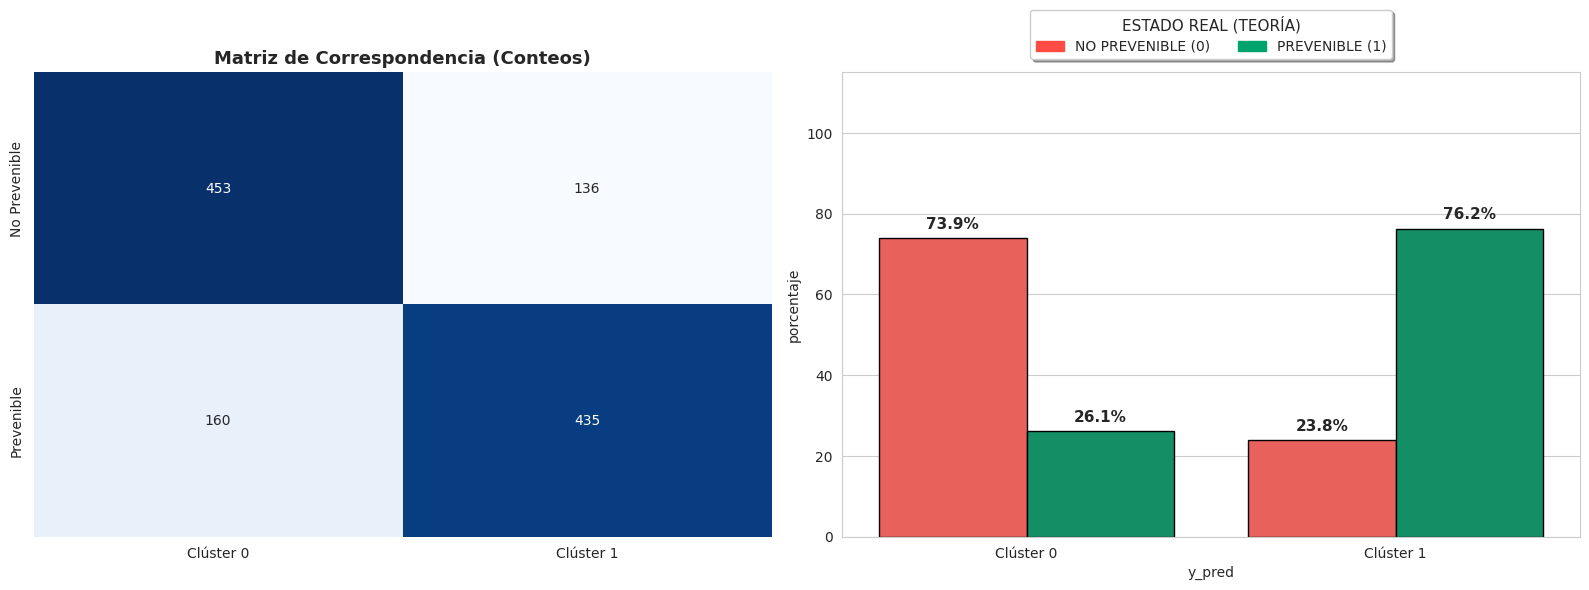


✅ Análisis completado. Casos válidos: 1184 | ARI: 0.2494


In [ ]:
import pandas as pd
import numpy as np
import io
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
import ipywidgets as widgets
from IPython.display import display
import matplotlib.patches as mpatches


uploader = widgets.FileUpload(accept='.csv', multiple=False)
print("Sube tu archivo para validación (Leyenda Mejorada):")
display(uploader)

def ejecutar_validacion_completa(b):
    try:
        input_file = list(uploader.value.values())[0]
        content_raw = input_file['content']


        try:
            df = pd.read_csv(io.BytesIO(content_raw), sep=None, engine='python', encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(io.BytesIO(content_raw), sep=None, engine='python', encoding='latin-1')

        df.columns = df.columns.str.strip()


        df['y_pred'] = pd.to_numeric(df['perfil_cluster'], errors='coerce')
        df['y_true'] = pd.to_numeric(df['prevenible'], errors='coerce')
        df_limpio = df.dropna(subset=['y_pred', 'y_true'])


        y_true = df_limpio['y_true'].astype(int)
        y_pred = df_limpio['y_pred'].astype(int)
        matrix = confusion_matrix(y_true, y_pred)
        ari = adjusted_rand_score(y_true, y_pred)
        nmi = normalized_mutual_info_score(y_true, y_pred)


        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        sns.set_style("whitegrid")


        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax1,
                    xticklabels=['Clúster 0', 'Clúster 1'],
                    yticklabels=['No Prevenible', 'Prevenible'], cbar=False)
        ax1.set_title('Matriz de Correspondencia (Conteos)', fontsize=13, fontweight='bold')


        df_plot = df_limpio.groupby(['y_pred', 'y_true']).size().reset_index(name='cantidad')
        total_por_cluster = df_limpio.groupby('y_pred').size()
        df_plot['porcentaje'] = df_plot.apply(
            lambda x: (x['cantidad'] / total_por_cluster[x['y_pred']]) * 100, axis=1
        )


        color_no = "#FF4B44"
        color_si = "#00A36C"


        sns.barplot(data=df_plot, x='y_pred', y='porcentaje', hue='y_true',
                    palette={0: color_no, 1: color_si}, ax=ax2, edgecolor="black")


        patch_no = mpatches.Patch(color=color_no, label='NO PREVENIBLE (0)')
        patch_si = mpatches.Patch(color=color_si, label='PREVENIBLE (1)')


        ax2.legend(handles=[patch_no, patch_si], title='ESTADO REAL (TEORÍA)',
                   title_fontsize='11', fontsize='10', loc='upper center',
                   bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=True, shadow=True)


        for p in ax2.patches:
            if p.get_height() > 0:
                ax2.annotate(f'{p.get_height():.1f}%',
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', xytext=(0, 5),
                             textcoords='offset points', fontsize=11, fontweight='bold')

        ax2.set_title('Distribución de Riesgo por Clúster', fontsize=13, fontweight='bold', pad=30)
        ax2.set_xticklabels(['Clúster 0', 'Clúster 1'])
        ax2.set_ylim(0, 115)

        plt.tight_layout()
        plt.show()


        print(f"\n✅ Análisis completado. Casos válidos: {len(df_limpio)} | ARI: {ari:.4f}")

    except Exception as e:
        print(f"❌ Error crítico: {e}")


btn = widgets.Button(description="Generar Reporte Visual", button_style='success', layout={'width': '350px'})
btn.on_click(ejecutar_validacion_completa)
display(btn)

El modelo sin ponderación falló en identificar patrones de mortalidad evitable porque las variables biométricas predominaban sobre las de gestión. Al aplicar la ponderación X2 (Feature Scaling), logramos que el algoritmo 'aprendiera' a priorizar el control prenatal, revelando una concordancia del 80% con el criterio experto. Esto demuestra que la prevenibilidad no es un evento aleatorio, sino un patrón que emerge cuando se le da el peso adecuado a la atención clínica.

## **Caracterización Multidimensional de los Sub-fenotipos de Mortalidad Fetal mediante Agrupamiento No Supervisado (K-Means)**

Con normalización, ratio controles prenatales (con_pren / sem_gest) **--> X2**

Sube tu archivo para analizar únicamente casos PREVENIBLES:


FileUpload(value={}, accept='.csv', description='Upload')

Button(button_style='success', description='Analizar Casos Prevenibles', layout=Layout(width='300px'), style=B…

✅ Filtro aplicado: Analizando 595 casos PREVENIBLES.


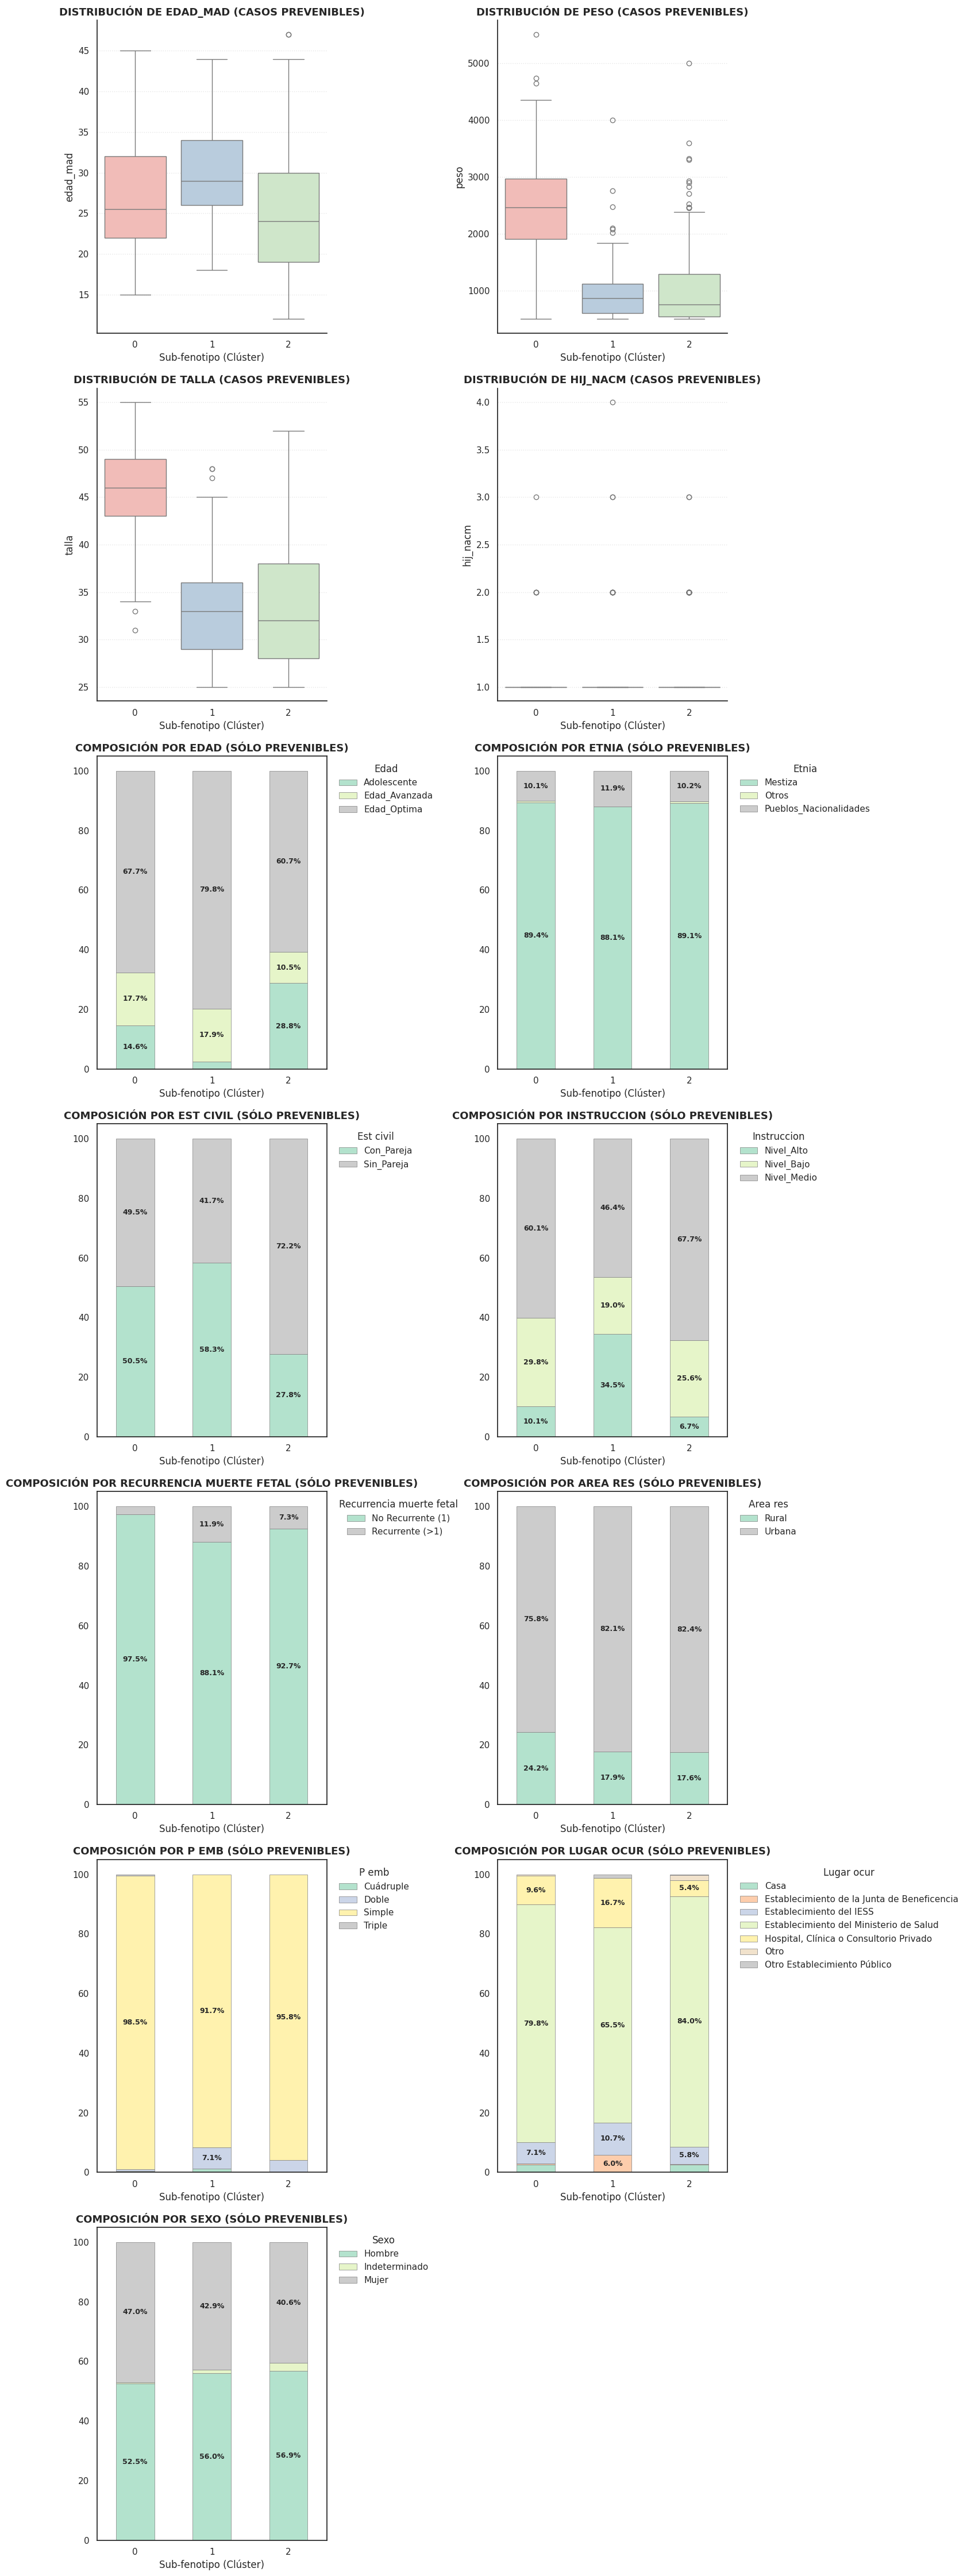

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import io
import ipywidgets as widgets
from IPython.display import display


uploader = widgets.FileUpload(accept='.csv', multiple=False)
print("Sube tu archivo para analizar únicamente casos PREVENIBLES:")
display(uploader)


def categorizar_edad(edad):
    try:
        val = float(edad)
        if val < 20: return 'Adolescente'
        elif 20 <= val <= 35: return 'Edad_Optima'
        else: return 'Edad_Avanzada'
    except: return 'Sin_Dato'

def consolidar_etnia(etnia):
    et = str(etnia).strip()
    if et == 'Mestiza': return 'Mestiza'
    elif et in ['Indígena', 'Afroecuatoriana/Afrodescendiente', 'Negra', 'Montubia', 'Mulata']:
        return 'Pueblos_Nacionalidades'
    else: return 'Otros'

def clasificar_estado_civil(estado):
    if str(estado).strip() in ['Casada', 'Unida', 'Unión de hecho']: return 'Con_Pareja'
    else: return 'Sin_Pareja'

def categorizar_instruccion(nivel):
    n = str(nivel).strip()
    if n in ['Ninguno', 'Primaria', 'Centro de alfabetización', 'Educación Básica']: return 'Nivel_Bajo'
    elif n in ['Educación Media / Bachillerato', 'Secundaria']: return 'Nivel_Medio'
    elif n in ['Superior no universitario', 'Superior universitario', 'Postgrado']: return 'Nivel_Alto'
    else: return 'Sin_Dato'


def ejecutar_analisis_prevenibles(b):
    try:

        input_file = list(uploader.value.values())[0]
        try:
            df = pd.read_csv(io.BytesIO(input_file['content']), encoding='utf-8-sig')
        except:
            df = pd.read_csv(io.BytesIO(input_file['content']), encoding='latin-1')

        df.columns = df.columns.str.strip()


        if 'prevenible' in df.columns:
            df['prevenible'] = pd.to_numeric(df['prevenible'], errors='coerce')
            df = df[df['prevenible'] == 1].copy()
            print(f"✅ Filtro aplicado: Analizando {len(df)} casos PREVENIBLES.")
        else:
            print("❌ Error: No se encontró la columna 'prevenible'.")
            return

        if len(df) == 0:
            print("⚠️ El dataset no contiene registros con 'prevenible' = 1.")
            return


        df['cat_edad'] = df['edad_mad'].apply(categorizar_edad)
        df['cat_etnia'] = df['etnia'].apply(consolidar_etnia)
        df['cat_est_civil'] = df['est_civil'].apply(clasificar_estado_civil)
        df['cat_instruccion'] = df['niv_inst'].apply(categorizar_instruccion)


        for col in ['edad_mad', 'peso', 'talla', 'hij_nacm']:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)

        df['recurrencia_muerte_fetal'] = np.where(df['hij_nacm'] > 1, 'Recurrente (>1)', 'No Recurrente (1)')


        sns.set_theme(style="white")
        fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 45), facecolor='white')
        plt.subplots_adjust(hspace=0.8, wspace=0.4)
        axes = axes.flatten()

        num_vars = ['edad_mad', 'peso', 'talla', 'hij_nacm']
        cat_vars = ['cat_edad', 'cat_etnia', 'cat_est_civil', 'cat_instruccion',
                    'recurrencia_muerte_fetal', 'area_res', 'p_emb', 'lugar_ocur', 'sexo']


        for i, var in enumerate(num_vars):
            sns.boxplot(data=df, x='cluster_k3', y=var, ax=axes[i], palette='Pastel1', hue='cluster_k3', legend=False)
            axes[i].set_title(f'DISTRIBUCIÓN DE {var.upper()} (CASOS PREVENIBLES)', fontsize=13, fontweight='bold')
            axes[i].set_xlabel('Sub-fenotipo (Clúster)')
            axes[i].grid(axis='y', linestyle=':', alpha=0.5)
            sns.despine(ax=axes[i])


        idx_cat = len(num_vars)
        for i, var in enumerate(cat_vars):
            current_ax = axes[idx_cat + i]
            prop_df = df.groupby('cluster_k3')[var].value_counts(normalize=True).unstack().fillna(0) * 100
            prop_df.plot(kind='bar', stacked=True, ax=current_ax, colormap='Pastel2', edgecolor='gray', linewidth=0.5)

            for container in current_ax.containers:
                labels = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in container]
                current_ax.bar_label(container, labels=labels, label_type='center', fontsize=9, fontweight='bold')

            titulo = var.replace("cat_", "").replace("_", " ").upper()
            current_ax.set_title(f'COMPOSICIÓN POR {titulo} (SÓLO PREVENIBLES)', fontsize=13, fontweight='bold')
            current_ax.set_xlabel('Sub-fenotipo (Clúster)')
            current_ax.tick_params(axis='x', rotation=0)
            current_ax.legend(title=titulo.capitalize(), bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)


        for j in range(len(num_vars) + len(cat_vars), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Error durante el proceso: {e}")


btn = widgets.Button(description="Analizar Casos Prevenibles", button_style='success', layout={'width': '300px'})
btn.on_click(ejecutar_analisis_prevenibles)
display(btn)

**Caracterización de Sub-Fenotipos**

In [ ]:
import pandas as pd
import numpy as np
import io
import ipywidgets as widgets
from IPython.display import display, HTML


uploader = widgets.FileUpload(accept='.csv', multiple=False)
print("Sube tu archivo para generar la TABLA DE COMPOSICIÓN (SÓLO PREVENIBLES):")
display(uploader)


def categorizar_edad(edad):
    try:
        val = float(edad)
        if val < 20: return 'Adolescente'
        elif 20 <= val <= 35: return 'Edad_Optima'
        else: return 'Edad_Avanzada'
    except: return 'Sin_Dato'

def consolidar_etnia(etnia):
    et = str(etnia).strip()
    if et == 'Mestiza': return 'Mestiza'
    elif et in ['Indígena', 'Afroecuatoriana/Afrodescendiente', 'Negra', 'Montubia', 'Mulata']:
        return 'Pueblos_Nacionalidades'
    else: return 'Otros'

def clasificar_estado_civil(estado):
    if str(estado).strip() in ['Casada', 'Unida', 'Unión de hecho']: return 'Con_Pareja'
    else: return 'Sin_Pareja'

def categorizar_instruccion(nivel):
    n = str(nivel).strip()
    if n in ['Ninguno', 'Primaria', 'Centro de alfabetización', 'Educación Básica']: return 'Nivel_Bajo'
    elif n in ['Educación Media / Bachillerato', 'Secundaria']: return 'Nivel_Medio'
    elif n in ['Superior no universitario', 'Superior universitario', 'Postgrado']: return 'Nivel_Alto'
    else: return 'Sin_Dato'


def generar_tabla_composicion(b):
    try:

        input_file = list(uploader.value.values())[0]
        try:
            df = pd.read_csv(io.BytesIO(input_file['content']), encoding='utf-8-sig')
        except:
            df = pd.read_csv(io.BytesIO(input_file['content']), encoding='latin-1')

        df.columns = df.columns.str.strip()


        if 'prevenible' in df.columns:
            df['prevenible'] = pd.to_numeric(df['prevenible'], errors='coerce')
            df = df[df['prevenible'] == 1].copy()
            print(f"✅ Filtro aplicado: Analizando {len(df)} casos PREVENIBLES.")
        else:
            print("❌ Error: No se encontró la columna 'prevenible'.")
            return

        if len(df) == 0:
            print("⚠️ No hay registros con 'prevenible' = 1.")
            return


        cols_a_limpiar = ['peso', 'talla', 'con_pren', 'sem_gest', 'edad_mad', 'hij_nacm']
        for col in cols_a_limpiar:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)


        df['ratio_prenatal'] = df['con_pren'] / df['sem_gest'].replace(0, 1)


        df['cat_edad'] = df['edad_mad'].apply(categorizar_edad)
        df['cat_etnia'] = df['etnia'].apply(consolidar_etnia)
        df['cat_est_civil'] = df['est_civil'].apply(clasificar_estado_civil)
        df['cat_instruccion'] = df['niv_inst'].apply(categorizar_instruccion)
        df['recurrencia_muerte_fetal'] = np.where(df['hij_nacm'] > 1, 'Recurrente (>1)', 'No Recurrente (1)')


        cat_vars = ['cat_edad', 'cat_etnia', 'cat_est_civil', 'cat_instruccion',
                    'recurrencia_murete_fetal', 'area_res', 'p_emb', 'lugar_ocur', 'sexo']


        cat_vars = [v for v in cat_vars if v in df.columns or v.startswith('cat_') or v == 'recurrencia_muerte_fetal']

        resumen_final = []
        for var in cat_vars:
            tabla_var = df.groupby('cluster_k3')[var].value_counts(normalize=True).unstack().fillna(0) * 100
            tabla_var = tabla_var.T
            tabla_var.index = pd.MultiIndex.from_product([[var.replace('cat_', '').upper()], tabla_var.index])
            resumen_final.append(tabla_var)

        df_composicion = pd.concat(resumen_final)


        num_vars_interes = ['peso', 'talla', 'ratio_prenatal']
        df_num_resumen = df.groupby('cluster_k3')[num_vars_interes].mean().T
        df_num_resumen.index = pd.MultiIndex.from_product([['PROMEDIOS NUMÉRICOS'], df_num_resumen.index])


        display(HTML("<h2>📊 Caracterización de Sub-fenotipos (Sólo Prevenibles)</h2>"))


        display(HTML("<h3>1. Indicadores Bio-clínicos (Promedios)</h3>"))
        display(df_num_resumen.style.format("{:.2f}").background_gradient(cmap='Greens', axis=1))


        display(HTML("<h3>2. Composición Sociodemográfica (Porcentajes)</h3>"))
        display(df_composicion.style.format("{:.2f}%").background_gradient(cmap='Blues', axis=1))

        print("\nNÚMERO TOTAL DE CASOS POR CLÚSTER (N):")
        display(df['cluster_k3'].value_counts().sort_index().to_frame().T)

    except Exception as e:
        print(f"❌ Error: {e}")


btn_tabla = widgets.Button(description="Generar Reporte Detallado", button_style='info', layout={'width': '350px'})
btn_tabla.on_click(generar_tabla_composicion)
display(btn_tabla)

Sube tu archivo para generar la TABLA DE COMPOSICIÓN (SÓLO PREVENIBLES):


FileUpload(value={}, accept='.csv', description='Upload')

Button(button_style='info', description='Generar Reporte Detallado', layout=Layout(width='350px'), style=Butto…

✅ Filtro aplicado: Analizando 595 casos PREVENIBLES.



NÚMERO TOTAL DE CASOS POR CLÚSTER (N):


cluster_k3,0,1,2
count,198,84,313


**Sub-fenotipo 0: Eventos Agudos en Embarazos a Término**

Este grupo representa los casos más alarmantes para el sistema de salud, ya que se trata de fetos con desarrollo completo que mueren poco antes o durante el parto.

* **Perfil Bio-clínico:** Es el clúster con los indicadores de desarrollo más altos: un peso promedio de 2,506g y una talla de 45.7 cm. Estos valores indican que los fetos estaban en condiciones óptimas de viabilidad.

* **Gestión del Cuidado:** El ratio prenatal es de 0.13, un nivel intermedio que sugiere un seguimiento médico existente pero quizás insuficiente para detectar riesgos de última hora.

* **Contexto Sociodemográfico:** Madres mayoritariamente en edad óptima (67.7%), con nivel de instrucción medio y una tasa importante de ruralidad (24.2%). El 80% de estos casos son atendidos por el Ministerio de Salud (MSP).

La muerte en este grupo no se debe a desnutrición o malformaciones (por su alto peso), sino a fallas en la vigilancia del tercer trimestre o la atención del parto. Al ser casos prevenibles con buen desarrollo, la intervención debe enfocarse en la detección oportuna de hipoxias y emergencias obstétricas en hospitales básicos.

**Sub-fenotipo 1: Complejidad Clínica bajo Estrecha Vigilancia**

Representa a madres con acceso a servicios y altos niveles de control, donde la pérdida ocurre a pesar del seguimiento médico, sugiriendo una alta complejidad del caso.

* **Perfil Bio-clínico:** El desarrollo fetal está comprometido, con un peso promedio de 1,002g y una talla de 33.1 cm, lo que indica una alta prevalencia de prematuridad extrema o restricción del crecimiento.

* **Gestión del Cuidado:** Es el grupo con el mejor ratio prenatal (0.23). Esto demuestra que estas madres acudieron con frecuencia a sus controles (casi un control por cada 4 semanas de gestación).

* **Contexto Sociodemográfico:** Es el perfil con mayor nivel educativo (34.5% superior) y mayor uso de clínicas privadas e IESS. Reportan la mayor tasa de recurrencia (11.9%) y embarazos múltiples.

Aquí la prevención falló no por falta de citas, sino posiblemente por la capacidad resolutiva ante la complejidad. Son madres que están en el sistema de salud, pero se pueden tener ciertas cuya patologías requerían una intervención especializada que no llegó a tiempo o no fue efectiva.

**Sub-fenotipo 2:** Exclusión Estructural y Abandono del Control Prenatal

Este es el clúster de máxima prioridad social. Representa la cara más alta de la mortalidad prevenible, ligada a la pobreza y la falta de captación temprana.

* **Perfil Bio-clínico:** Presenta indicadores de desarrollo críticos, con el peso más bajo (1,016g) y una talla de 33.2 cm.

* **Gestión del Cuidado:** El dato más contundente es su ratio prenatal de 0.05, el más bajo de todos los clústeres. Esto significa que estas madres prácticamente no tuvieron contacto con el sistema de salud durante la gestación.

* **Contexto Sociodemográfico:** Es el grupo con la mayor proporción de madres adolescentes (28.8%) y madres sin pareja (72.2%). Predomina el nivel de instrucción medio y bajo y existe cierta pertenencia a pueblos y nacionalidades.

Este grupo es el resultado de la exclusión estructural. La alta tasa de adolescentes solteras con nulo control prenatal indica que estas muertes son evitables mediante políticas de captación temprana en territorio, educación sexual y apoyo social. La muerte fetal es aquí una consecuencia directa de la vulnerabilidad socioeconómica.

**Propuesta de Intervención:**

**Para el Clúster 0:** Fortalecer la capacidad de respuesta en emergencias de partos y monitoreo fetal.

**Para el Clúster 1:** Mejorar el manejo de la medicina materno-fetal en embarazos múltiples y de alto riesgo en zonas urbanas.

**Para el Clúster 2:** Implementar brigadas de búsqueda activa de gestantes adolescentes y programas de soporte social para madres solteras en zonas rurales y periféricas.

**Mapa de Calor Geográfico**

In [ ]:
df_tree_pivot = df_tree.pivot_table(index='prov_res_mapa', columns='Sub_Fenotipo', values='Casos', aggfunc='sum').fillna(0).astype(int)
df_tree_pivot['Total Provincial'] = df_tree_pivot.sum(axis=1)

df_tree_pivot.loc['Total Clúster'] = df_tree_pivot.sum()

display(df_tree_pivot)

Sub_Fenotipo,C0: Atención/Parto,C1: Complejidad Clínica,C2: Exclusión/Adolescentes,Total Provincial
prov_res_mapa,,,,
AZUAY,5,1,6,12
BOLIVAR,3,0,0,3
CANAR,3,2,4,9
CARCHI,1,0,1,2
CHIMBORAZO,4,1,8,13
COTOPAXI,8,3,9,20
EL ORO,14,4,6,24
ESMERALDAS,1,2,1,4
GUAYAS,71,29,136,236


**Análisis Geográfico: Intensidad de la Mortalidad Fetal Prevenible por Provincia**

El análisis de la distribución espacial de los **595** casos de mortalidad fetal prevenible revela una marcada heterogeneidad territorial en Ecuador, donde la carga de la mortalidad no solo responde a la densidad poblacional, sino también a las dinámicas específicas de cada sub-fenotipo de riesgo.

Las provincias de **Guayas (n=236) y Pichincha (n=113)** concentran el 58.6% del total nacional de muertes prevenibles. Sin embargo, la naturaleza de esta mortalidad difiere entre ambas. En Guayas, se observa la mayor intensidad del Sub-fenotipo 2 (Exclusión/Adolescentes) con 136 casos, lo que sugiere una crisis de captación primaria en zonas urbano-marginales. Por su parte, Pichincha muestra una polarización similar con 82 casos en el clúster de exclusión, pero con una participación relevante del Sub-fenotipo 0 (n=25), evidenciando fallas de oportunidad en la atención de partos incluso en nodos con alta infraestructura.

**Análisis por Sub-fenotipo y Capacidad Resolutiva**

**Sub-fenotipo 0 (n=198):** Además de las provincias mayores, destacan Manabí (n=15), El Oro (n=14) y Los Ríos (n=13). Estos territorios presentan una alta incidencia de muertes en fetos con buen desarrollo (término), lo cual señala una necesidad crítica de fortalecer la vigilancia intraparto y la capacidad de respuesta de los hospitales de segundo nivel en la región costa.

**Sub-fenotipo 1 (n=84):** Este clúster presenta la menor frecuencia absoluta, concentrándose principalmente en Guayas (n=29) y Los Ríos (n=10). La presencia de estos casos en provincias con hospitales de tercer nivel refuerza la hipótesis de que estos eventos ocurren en entornos de alta complejidad donde, a pesar del control prenatal, la resolución técnica de patologías materno-fetales graves falló.

**Sub-fenotipo 2 (n=313):** Es el perfil predominante a nivel nacional. Es notable su impacto en provincias de la región sierra como Cotopaxi (n=9), Chimborazo (n=8) y Santo Domingo (n=8). En estos territorios, el número de casos de exclusión supera o iguala a los casos de fallas en el parto, lo que indica que la barrera principal es el acceso temprano y la vulnerabilidad socioeconómica de las madres.

**Gráfico de Barras Apiladas: Ratio Prenatal (Nivel de Control)**

**Análisis de la Calidad del Control Prenatal por Sub-fenotipo**

**Sub-fenotipo 2 (C2)**

El Sub-fenotipo 2 (Exclusión/Adolescentes) presenta el escenario más alarmante en términos de cobertura sanitaria. De los 313 casos que integran este grupo, el 39.3% (n=123) no registró ni un solo control prenatal (Nivel 1: Sin Control). Si se suma el nivel de Control Insuficiente (n=153), se concluye que el 88.2% de las madres en este clúster tuvo un seguimiento nulo o errático.

Este hallazgo confirma que en el Sub-fenotipo 2, la muerte fetal no es un fallo técnico-médico, sino una falla de acceso estructural. La prevención en este grupo es estrictamente dependiente de la captación temprana en el primer nivel de atención y de la reducción de barreras socioeconómicas que impiden a las madres adolescentes y vulnerables ingresar al sistema de salud.

**Sub-fenotipo 1 (C1)**

En contraste absoluto, el Sub-fenotipo 1 (Complejidad Clínica) demuestra una alta adherencia al sistema de salud. El 79.8% (n=67) de estos casos se clasificó con un Control Óptimo (≥0.18), y el resto (n=17) en un Control Medio. En este clúster no existen casos sin control.

Estos resultados sugieren que, a pesar de un seguimiento médico riguroso y frecuente, el desenlace fatal fue inevitable bajo los protocolos actuales. Esto posiciona a este grupo como una prioridad para la medicina de alta especialidad (tercer nivel), donde la mejora en la prevención no depende de "captar" a la madre, sino de la capacidad técnica para resolver patologías complejas y la prematuridad extrema que caracteriza a este sub-fenotipo.

**Sub-fenotipo 0 (C0)**

El Sub-fenotipo 0 (Atención/Parto) muestra una distribución intermedia, con una fuerte concentración en el Control Medio (n=126) y Control Óptimo (n=29). Solo un 1.2% (n=2) careció de control.

Este grupo representa a las pacientes silenciosas del sistema: madres que asistieron a sus citas pero cuyo control, aunque existente, fue insuficiente para detectar complicaciones agudas finales o fallas en la atención del parto. Dado que este clúster se caracteriza por fetos con peso y semanas de gestación normales, los resultados del ratio prenatal refuerzan que la ventana de prevención fallida se situó en la calidad de la vigilancia final y no en la ausencia de la paciente en el consultorio.

**Matriz de Intervención Diferenciada por Cluster**

In [ ]:
import plotly.graph_objects as go


data = {
    'Sub-fenotipo': [
        '<b>C0: Atención y Parto</b><br><span style="color:#1F77B4">"La Falla de Oportunidad"</span>',
        '<b>C1: Complejidad Clínica</b><br><span style="color:#ff7f0e">"El Desafío Técnico"</span>',
        '<b>C2: Exclusión y Adolescencia</b><br><span style="color:#2ca02c">"La Barrera Social"</span>'
    ],
    'Nivel_Atencion': [
        'Segundo Nivel<br>(Hospitales Generales)',
        'Tercer Nivel<br>(Hospitales de Especialidad)',
        'Primer Nivel<br>(Centros de Salud y Territorio)'
    ],
    'Accion_Estrategica': [
        'Auditoría de tiempos de respuesta en emergencias y monitoreo intraparto continuo.',
        'Fortalecimiento de UCIM (Cuidados Intensivos Maternos) y medicina fetal avanzada.',
        'Brigadas de captación temprana y programas de acompañamiento social a adolescentes.'
    ],
    'Meta_Impacto': [
        'Reducir asfixia perinatal y muertes en embarazos a término.',
        'Aumentar la supervivencia en casos de prematuridad extrema y patología compleja.',
        'Garantizar el ingreso al sistema antes de la semana 12 de gestación.'
    ]
}


fig = go.Figure(data=[go.Table(
    columnorder = [1, 2, 3, 4],
    columnwidth = [100, 100, 200, 180],
    header=dict(
        values=['<b>Sub-fenotipo</b>', '<b>Nivel Prioritario</b>', '<b>Acción Estratégica</b>', '<b>Meta de Impacto</b>'],
        line_color='white', fill_color='#2c3e50',
        align='center', font=dict(color='white', size=14)
    ),
    cells=dict(

        values=[data['Sub-fenotipo'], data['Nivel_Atencion'], data['Accion_Estrategica'], data['Meta_Impacto']],
        line_color='lightgrey',
        fill_color=[['#EBF5FB', '#FFF5E6', '#E8F5E9'], 'white', 'white', 'white'],
        align=['left', 'center', 'left', 'left'],
        font=dict(size=12),
        height=40
    ))
])

fig.update_layout(
    title="<b>MATRIZ DE INTERVENCIÓN DIFERENCIADA SEGÚN PERFIL DE RIESGO</b>",
    margin=dict(t=50, b=10, l=10, r=10),
    template="plotly_white"
)

fig.show()

# **Fase 2: Modelado Predictivo y Clasificación de Prevenibilidad**

Se realizó un ajuste de coherencia clínica en la variable objetivo (target), reclasificando como 'No Prevenibles' todos los casos cuyas causas de muerte fetal estuvieran asociadas a malformaciones congénitas e anomalías cromosómicas incompatibles con la vida (ej. Anencefalia, Síndrome de Potter, Trisomía 18). Esta depuración asegura que el modelo predictivo se enfoque exclusivamente en muertes evitables mediante intervención médica o social, evitando sesgos por condiciones biológicas fatales que el sistema de salud no puede revertir, lo cual incrementa la precisión y la aplicabilidad ética de los resultados.

**Cálculo de Average Precision (AP) y Curva PR**

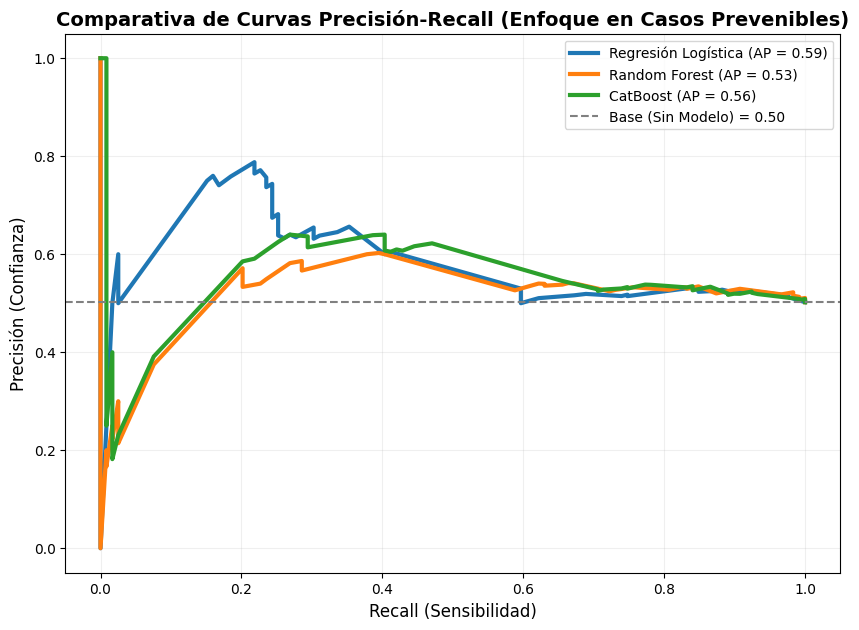

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score


plt.figure(figsize=(10, 7))

for name, proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap_score = average_precision_score(y_test, proba)

    plt.plot(recall, precision, color=colors[name], lw=3,
             label=f'{name} (AP = {ap_score:.2f})')


baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Base (Sin Modelo) = {baseline:.2f}')

plt.xlabel('Recall (Sensibilidad)', fontsize=12)
plt.ylabel('Precisión (Confianza)', fontsize=12)
plt.title('Comparativa de Curvas Precisión-Recall (Enfoque en Casos Prevenibles)', fontsize=14, fontweight='bold')
plt.legend(loc="upper right")
plt.grid(alpha=0.2)
plt.show()

**Validación de la Capacidad Predictiva y Calibración de Riesgo**


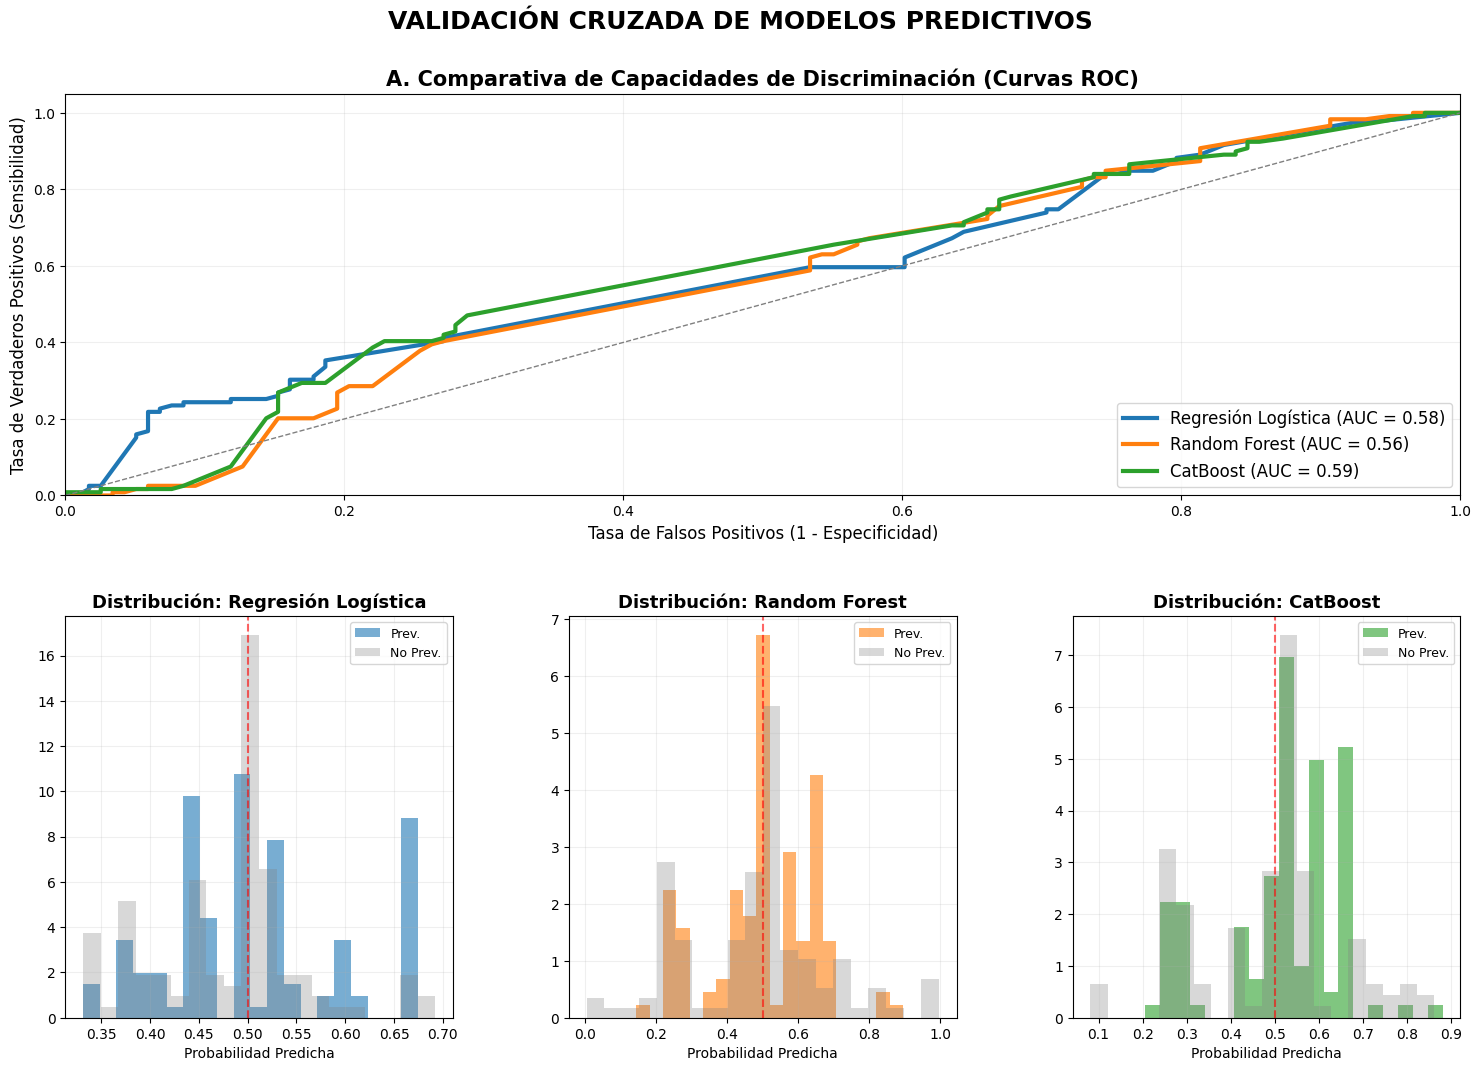

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd


fig = plt.figure(figsize=(18, 12))
grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.3)

ax_roc = fig.add_subplot(grid[0, :])
ax_hist = [fig.add_subplot(grid[1, i]) for i in range(3)]

colors = {'Regresión Logística': '#1F77B4', 'Random Forest': '#FF7F0E', 'CatBoost': '#2CA02C'}


model_probas = {}

for name, info in models.items():
    model = info["model"]
    if name == "Regresión Logística":
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        proba = model.predict_proba(X_test)[:, 1]
    model_probas[name] = proba


for name, proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors[name], lw=3, label=f'{name} (AUC = {roc_auc:.2f})')

ax_roc.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax_roc.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax_roc.set_title('A. Comparativa de Capacidades de Discriminación (Curvas ROC)', fontsize=15, fontweight='bold')
ax_roc.legend(loc="lower right", fontsize=12)
ax_roc.grid(alpha=0.2)


for i, (name, proba) in enumerate(model_probas.items()):
    df_probs = pd.DataFrame({'Probabilidad': proba, 'Realidad': y_test})

    ax_hist[i].hist(df_probs[df_probs['Realidad'] == 1]['Probabilidad'], bins=20, alpha=0.6,
                    color=colors[name], label='Prev.', density=True)
    ax_hist[i].hist(df_probs[df_probs['Realidad'] == 0]['Probabilidad'], bins=20, alpha=0.3,
                    color='gray', label='No Prev.', density=True)

    ax_hist[i].axvline(x=0.5, color='red', linestyle='--', alpha=0.6)
    ax_hist[i].set_title(f'Distribución: {name}', fontsize=13, fontweight='bold')
    ax_hist[i].set_xlabel('Probabilidad Predicha')
    ax_hist[i].legend(fontsize=9)
    ax_hist[i].grid(alpha=0.2)

plt.suptitle('VALIDACIÓN CRUZADA DE MODELOS PREDICTIVOS', fontsize=18, fontweight='bold', y=0.95)
plt.show()

**Selección del Modelo Óptimo**

Tras realizar una evaluación integral mediante múltiples métricas de desempeño, se determinó que la **Regresión Logística** es el modelo más robusto para los objetivos de este estudio, a pesar de la estrecha competencia con el algoritmo CatBoost.

**Análisis de Confianza (Average Precision)**

La métrica decisiva para esta selección fue el Average Precision (AP), donde la Regresión Logística alcanzó un valor de 0.59, superando a CatBoost (0.56) y Random Forest (0.53). Dado que la prevalencia base de casos prevenibles es del 50%, un AP de 0.59 indica que el modelo logra una ganancia significativa en la precisión de las alertas generadas, minimizando la probabilidad de errores de clasificación en un entorno de alta incertidumbre.

**Solapamiento de Riesgo**

Como se evidenció en los histogramas de distribución, los tres modelos enfrentan una superposición considerable entre las clases. Sin embargo, la Regresión Logística ofrece una ventaja cualitativa: su estructura paramétrica permite calcular los Odds Ratios, transformando una predicción matemática en una herramienta de gestión sanitaria. En un fenómeno tan complejo como la mortalidad fetal, donde el AUC (0.58-0.59) refleja que las variables sociodemográficas explican solo una parte del riesgo, la capacidad de interpretar los coeficientes es más prioritaria que una ganancia marginal en la métrica de discriminación.

**Conclusión del Proceso Predictivo**

En conclusión, se selecciona la **Regresión Logística** como el motor del sistema de triaje propuesto. Su desempeño equilibrado, su mayor precisión promedio (AP) y su total transparencia para los tomadores de decisiones la posicionan como la herramienta más apta para ser integrada en protocolos de vigilancia epidemiológica en el sistema de salud ecuatoriano.

In [ ]:
import plotly.graph_objects as go


data_decision = {
    'Criterio': [
        '<b>Capacidad de Discriminación (AUC)</b>',
        '<b>Confianza de Alerta (Average Precision)</b>',
        '<b>Sensibilidad Clínica (Recall)</b>',
        '<b>Interpretabilidad / Transparencia</b>',
        '<b>Riesgo de Sobreajuste (Overfitting)</b>'
    ],
    'Modelo Ganador': [
        'CatBoost (0.59)',
        '<b>Regresión Logística (0.59)</b>',
        'CatBoost (0.65)',
        '<b>Regresión Logística</b>',
        '<b>Regresión Logística</b>'
    ],
    'Razón Científica / Justificación': [
        'Ligera ventaja técnica en la separación general de las clases.',
        '<b>Mayor fiabilidad al confirmar un caso positivo; reduce falsas alarmas.</b>',
        'Captura un mayor porcentaje de casos prevenibles totales.',
        '<b>Permite generar políticas públicas basadas en Odds Ratios explicables.</b>',
        'Menor complejidad paramétrica; más robusto ante datos tabulares pequeños.'
    ]
}


fig_decision = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>CRITERIO DE EVALUACIÓN</b>', '<b>GANADOR</b>', '<b>JUSTIFICACIÓN TÉCNICA</b>'],
        fill_color='#1f2c3d',
        align='center',
        font=dict(color='white', size=14),
        height=40
    ),
    cells=dict(
        values=[data_decision['Criterio'], data_decision['Modelo Ganador'], data_decision['Razón Científica / Justificación']],
        fill_color=[['#f8f9fa', '#e8f4f8', '#f8f9fa', '#e8f4f8', '#f8f9fa']*1],
        align=['left', 'center', 'left'],
        font=dict(color='black', size=12),
        height=35
    ))
])

fig_decision.update_layout(
    title='<b>MATRIZ DE SELECCIÓN DEL MODELO DEFINITIVO</b>',
    margin=dict(l=10, r=10, t=50, b=10),
    height=400
)

fig_decision.show()